In [ ]:
import control as ct
import control.optimal as opt
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm
print("GOGOGO!!!")

# Linear quadratic
尝试构造一个线性二次系统，然后最优控制解出来看看

## sys

In [ ]:
linear_params = {'A': 1, 'B': 1}
def linear_update(t, x, u, params):
    A = params['A']
    B = params['B']
    return A * x[0] + B * u[0]

def linear_output(t, x, u, params):
    A = params['A']
    B = params['B']
    return A * x[0] + B * u[0]

linear_sys = ct.nlsys(updfcn=linear_update, 
                      outfcn=linear_output,
                      inputs=1, outputs=1, states=1,
                      params=linear_params,
                      name='linear_sys',
                      dt=1)

print(linear_sys)

## simulation

In [ ]:
timepts = np.arange(0, 10) # simulate for 10 time steps
response = ct.input_output_response(linear_sys, timepts, [2], [3]) # u = 2, x0 = 3
print(response)

In [ ]:
for t, y, u in zip(response.time, response.outputs, response.inputs):
    print(t, y, u)

## objective func

In [ ]:
Q = np.array([1])
R = np.array([1])
F = np.array([1.618])
running_cost = opt.quadratic_cost(linear_sys, Q, R)
terminal_cost = opt.quadratic_cost(linear_sys, F, None)

## solve ocp

In [ ]:
timepts = np.arange(0, 5, 1)
x0 = np.array([1])
constraints = []

result = opt.solve_ocp(linear_sys, timepts, x0, running_cost, constraints, terminal_cost)

In [ ]:
print(result)

In [ ]:
u = result.inputs
x = result.states
print(u/x)

# Cartpole test
1. 如何定义对应的非线性系统。
2. 如何定义想要的cost function。
3. 约束条件。
4. 时域和初始状态。
5. 求解！

## sys

In [80]:
class cartpole():
    def __init__(self, params=[9.8, 1.0, 0.1, 0.5]):
        self.params = params
        self.force_mag = 100.
        self.theta_threshold_radians = np.pi
        self.x_threshold = 2.4
        self.max_velocity = 10
        self.dt = 0.05
        self.lower = -self.force_mag
        self.upper = self.force_mag
        self.goal_state = [0., 0., 1., 0., 0.]
        self.goal_weights = [0.1, 0.1, 1., 1., 0.1]
        self.ctrl_penalty = 0.001
    
    def get_update_func(self):
        def cartpole_update(t, states, inputs, params):
            gravity, masscart, masspole, length = params
            total_mass = masspole + masscart
            polemass_length = masspole * length

            u = inputs[0]
            u = np.clip(u, self.lower, self.upper)

            x, dx, cos_th, sin_th, dth = states
            th = np.arctan2(sin_th, cos_th)

            cart_in = (u + polemass_length * dth**2 * sin_th) / total_mass
            th_acc = (gravity * sin_th - cos_th * cart_in) / \
                (length * (4./3. - masspole * cos_th**2 / total_mass))
            xacc = cart_in - polemass_length * th_acc * cos_th / total_mass

            x = x + self.dt * dx
            dx = dx + self.dt * xacc
            th = th + self.dt * dth
            dth = dth + self.dt * th_acc

            return np.array([x, dx, np.cos(th), np.sin(th), dth])
        return cartpole_update
    
    def get_frame(self, state, ax=None):
        x, dx, cos_th, sin_th, dth = state
        gravity, masscart, masspole, length = self.params

        th = np.arctan2(sin_th, cos_th)
        th_x = sin_th*length
        th_y = cos_th*length

        if ax is None:
            fig, ax = plt.subplots(figsize=(6,6))
        else:
            fig = ax.get_figure()
        ax.plot((x,x+th_x), (0, th_y), color='k')
        ax.set_xlim((-length*2, length*2))
        ax.set_ylim((-length*2, length*2))
        return fig, ax

    def get_true_obj(self):
        q = np.concatenate((self.goal_weights, [self.ctrl_penalty]))
        p = -np.sqrt(self.goal_weights) * self.goal_state
        return q, p

In [81]:
cartpole = cartpole()
cartpole_update = cartpole.get_update_func()
cartpole_sys = ct.nlsys(updfcn=cartpole_update, outfcn=cartpole_update, inputs=1, outputs=5, states=5, params=cartpole.params, name='cartpole_sys', dt=1)

## simulation

In [82]:
timepts = np.arange(0, 6, 1) # simulate for 10 time steps

x0 = cartpole.goal_state
response = ct.input_output_response(cartpole_sys, timepts, [-8], x0) # push the cartpole to the left
print(response)

[0.0, 0.0, 1.0, 0.0, 0.0]
[[ 0.         -0.0195122  -0.05853659 -0.11711949 -0.19532632 -0.29318459]
 [-0.3902439  -0.7804878  -1.17165814 -1.56413647 -1.95716554 -2.34794813]
 [ 1.          0.99957171  0.99614763  0.98442173  0.95585967  0.89817908]
 [ 0.          0.02926411  0.0876921   0.17582339  0.29382358  0.43962978]
 [ 0.58536585  1.17073171  1.77874504  2.42964826  3.13923799  3.9154983 ]]


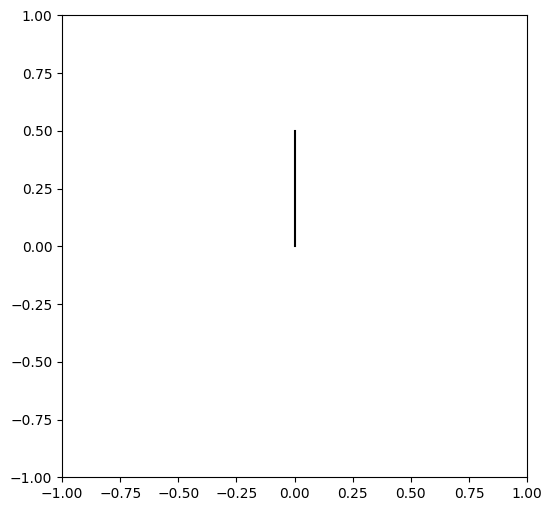

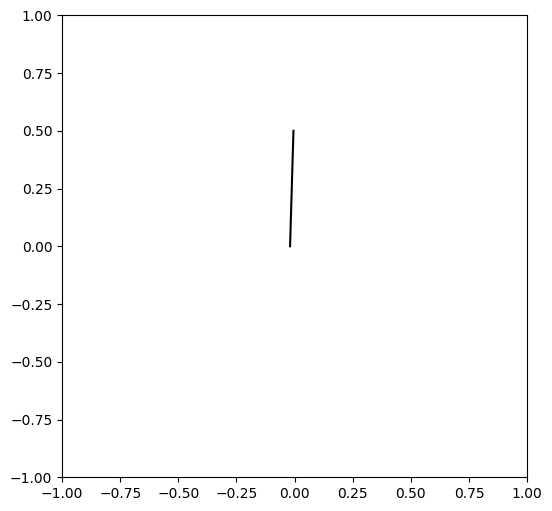

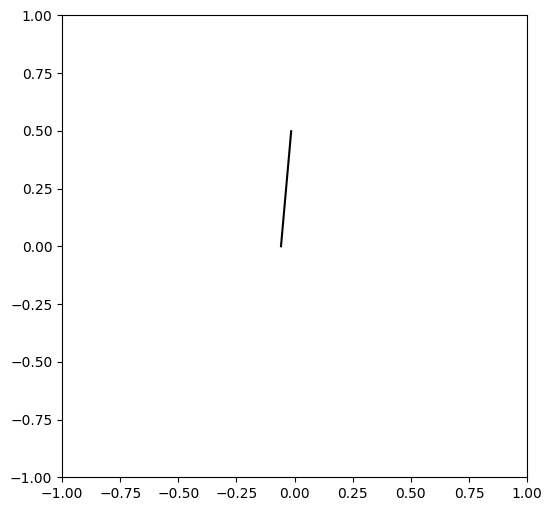

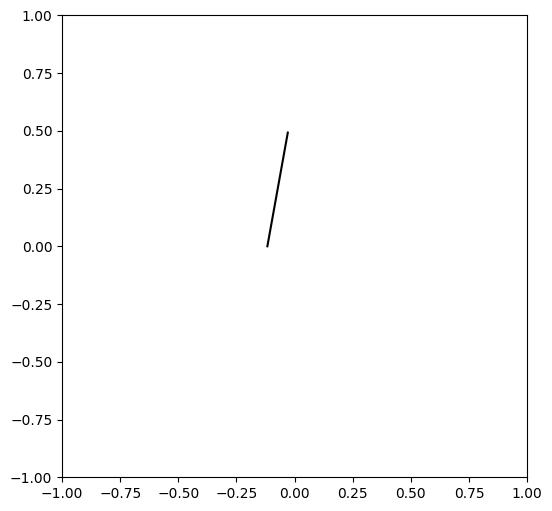

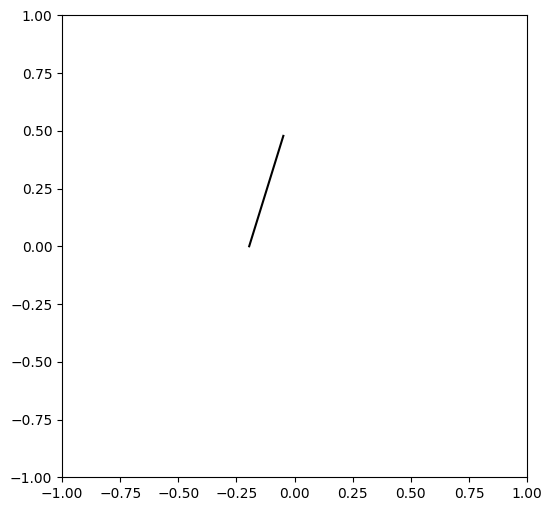

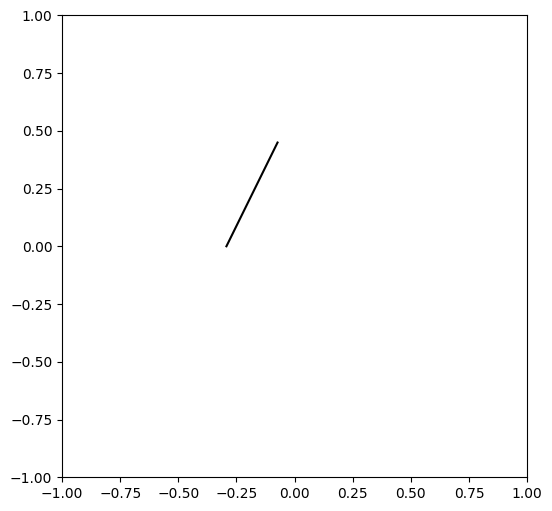

In [83]:
print(x0)
print(response.outputs)

for t in range(len(timepts)):
    cartpole.get_frame(response.outputs[:, t])

## constraints

In [84]:
constraints = [opt.input_range_constraint(cartpole_sys, cartpole.lower, cartpole.upper)]

## objective func

In [85]:
Q = np.eye(5)
R = np.eye(1) * cartpole.ctrl_penalty
F = np.eye(5) * 5
running_cost = opt.quadratic_cost(cartpole_sys, Q, R)
terminal_cost = opt.quadratic_cost(cartpole_sys, F, None)

## solve ocp

In [86]:
q, p = cartpole.get_true_obj()

In [87]:
print(q)
print(p)

[0.1   0.1   1.    1.    0.1   0.001]
[-0. -0. -1. -0. -0.]


In [88]:
# use q, p to construct Q, R, F
Q = np.diag(q[:-1])
R = np.diag(q[-1:])
F = np.diag([0, 0, 0, 0, 0])

running_cost = opt.quadratic_cost(cartpole_sys, Q, R)
terminal_cost = opt.quadratic_cost(cartpole_sys, F, None)

In [89]:
def uniform(shape, low, high):
    r = high - low
    return np.random.rand(*shape) * r + low

def cartpole_initx(n_batch):
    th = uniform((n_batch, 1), -2*np.pi, 2*np.pi)
    thdot = uniform((n_batch, 1), -.5, .5)
    x = uniform((n_batch, 1), -0.5, 0.5)
    xdot = uniform((n_batch, 1), -0.5, 0.5)
    xinit = np.concatenate((x, xdot, np.cos(th), np.sin(th), thdot), axis=1)
    return xinit

print(cartpole_initx(1)[0])

[ 0.06136616 -0.26054766  0.57147667  0.82061831  0.14229194]


In [90]:
timepts = np.arange(0, 100, 1)
x0 = cartpole_initx(1)[0]
result = opt.solve_ocp(cartpole_sys, timepts, x0, running_cost, constraints, terminal_cost)

Summary statistics:
* Cost function calls: 10118
* Constraint calls: 10320
* System simulations: 20320
* Final cost: 158.69211428627716


In [91]:
print(x0)
print(result.states[:, 0])
print(result.inputs[:, 0])

[ 0.31060081 -0.36218674  0.85827784 -0.5131853  -0.22911701]
[ 0.31060081 -0.36218674  0.85827784 -0.5131853  -0.22911701]
[12.35855062]


C:\Users\90534\AppData\Local\Temp\ipykernel_11992\402580229.py:49: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6,6))


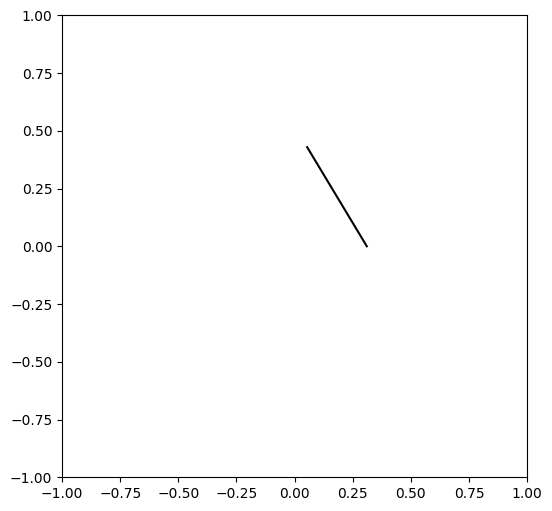

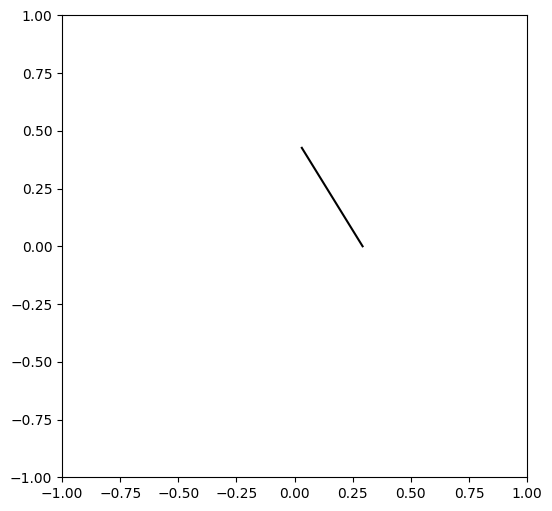

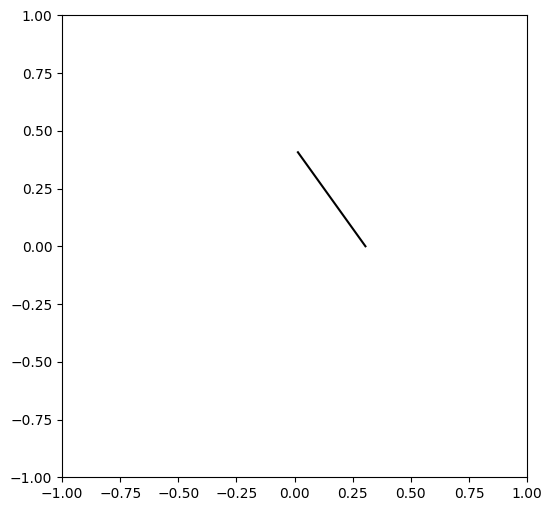

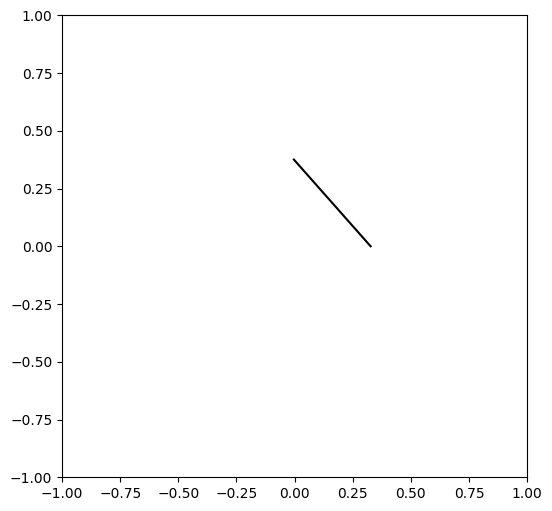

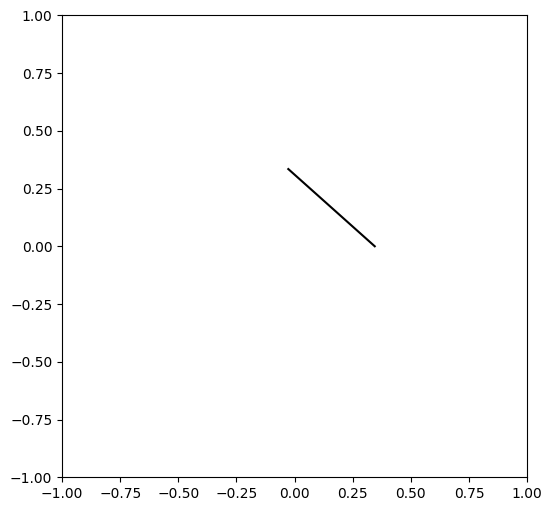

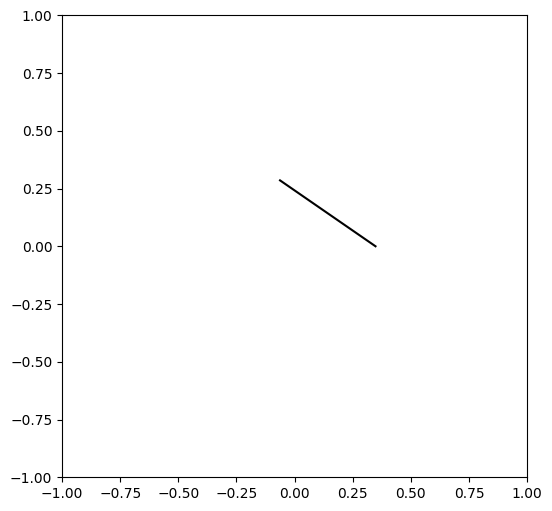

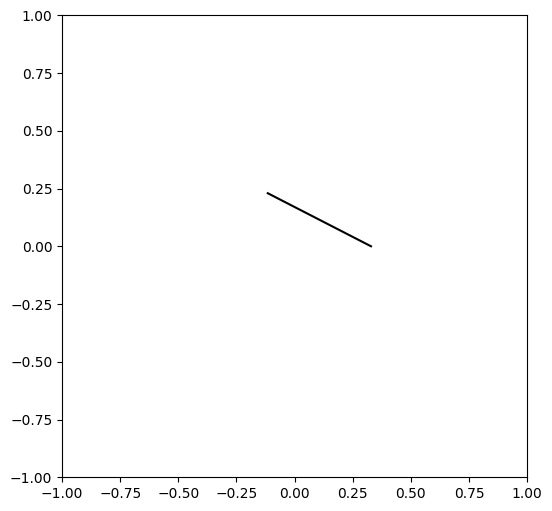

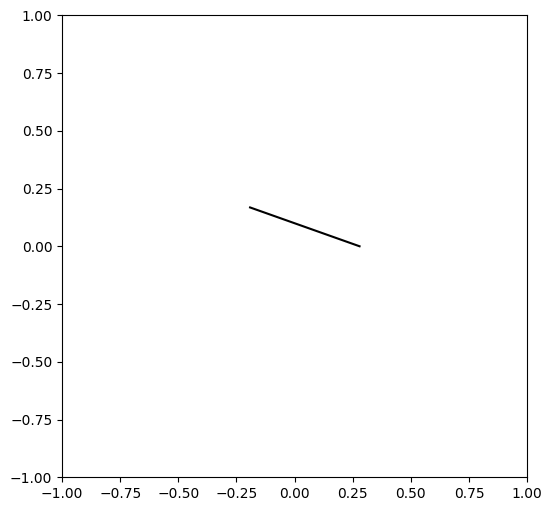

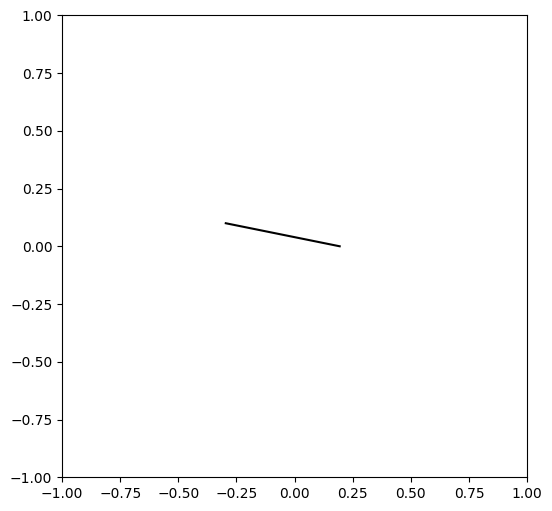

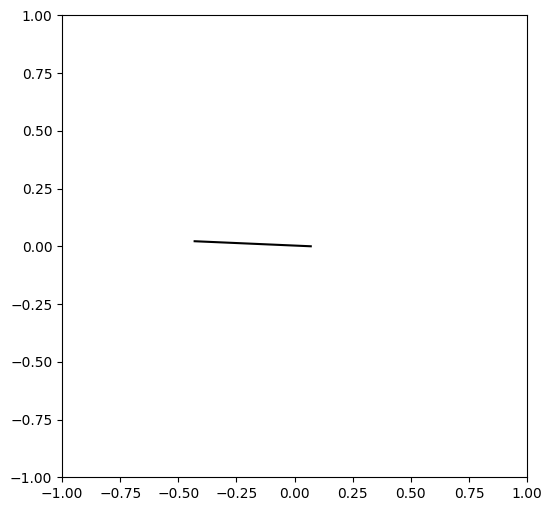

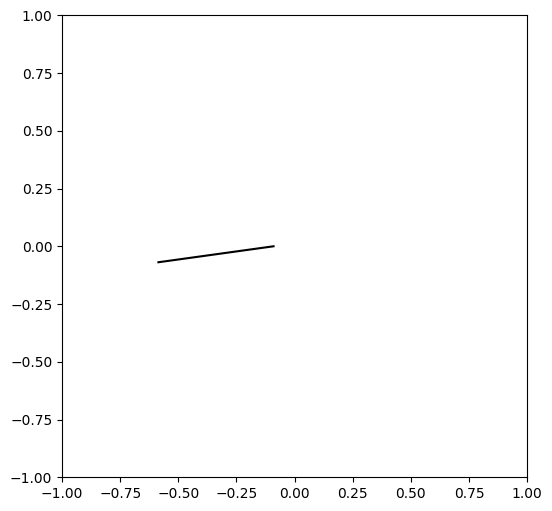

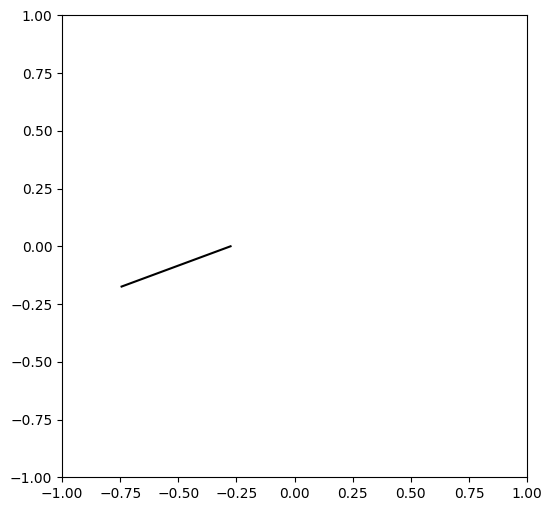

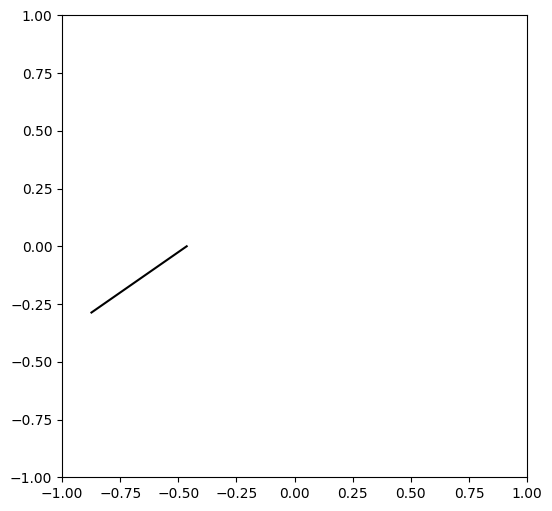

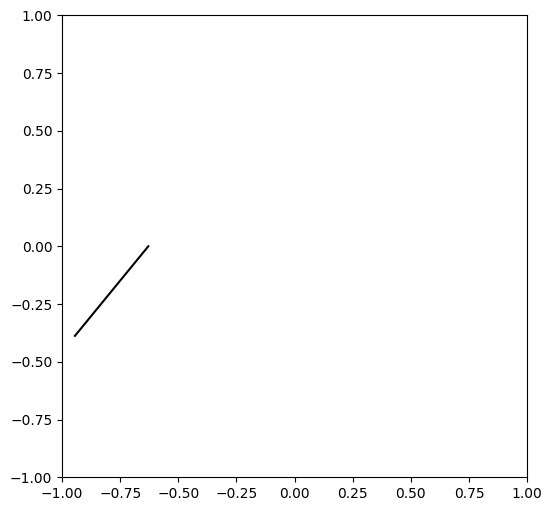

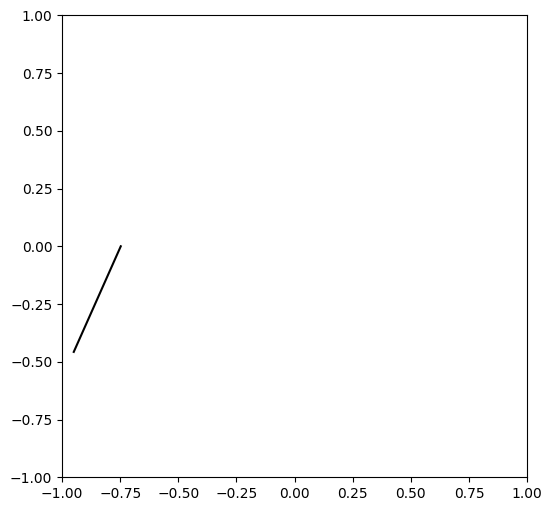

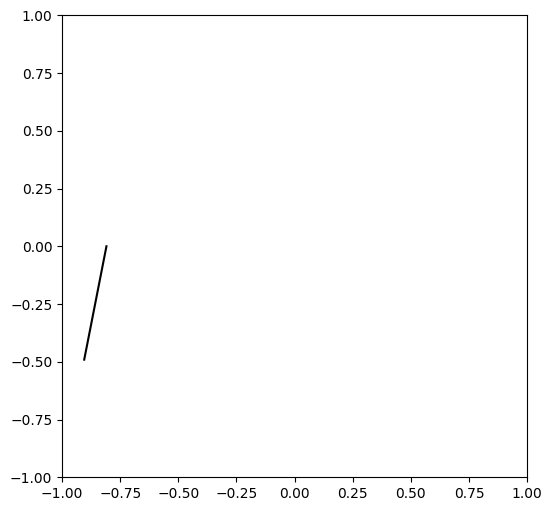

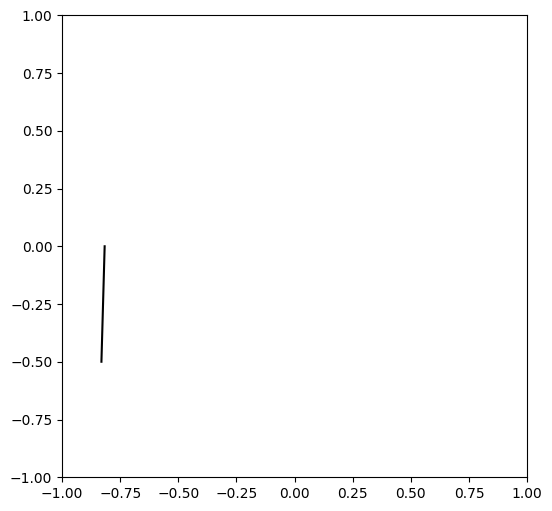

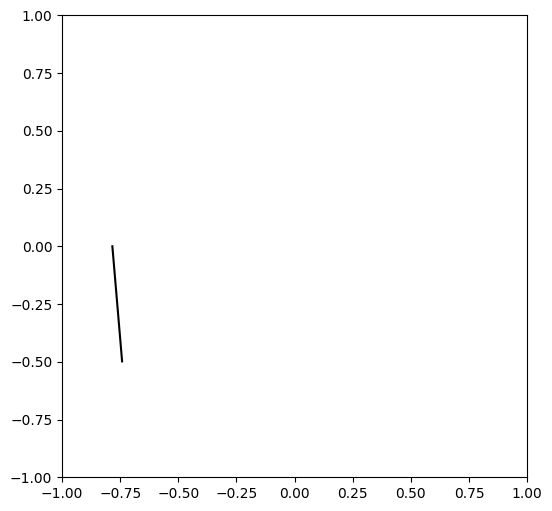

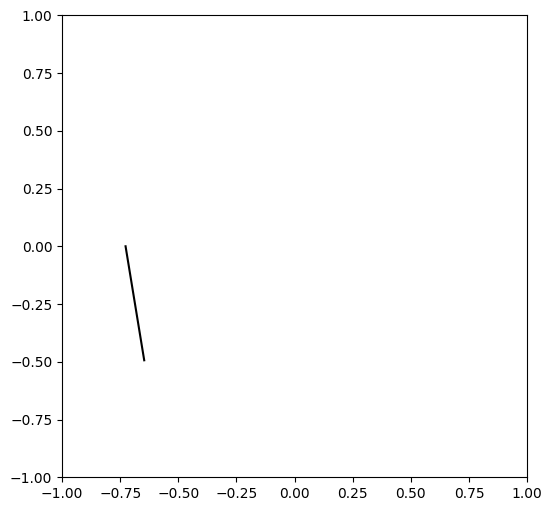

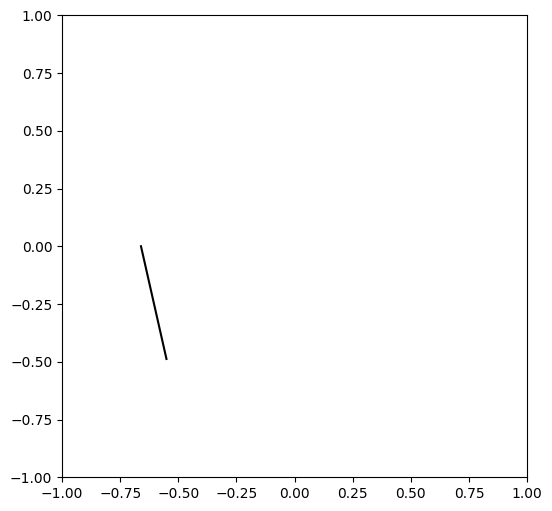

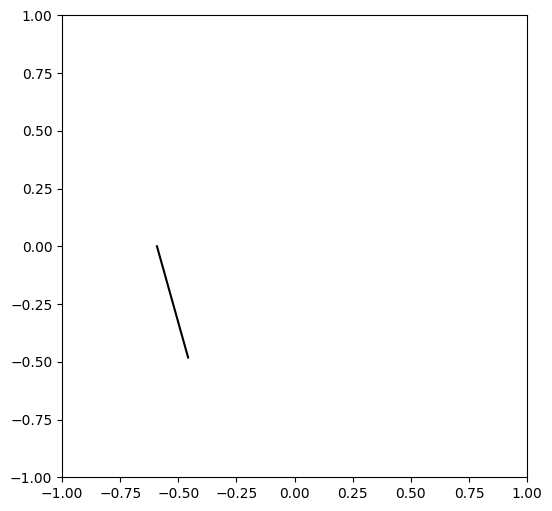

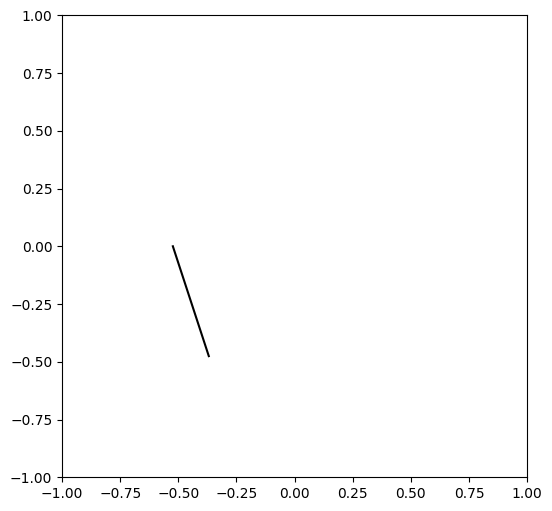

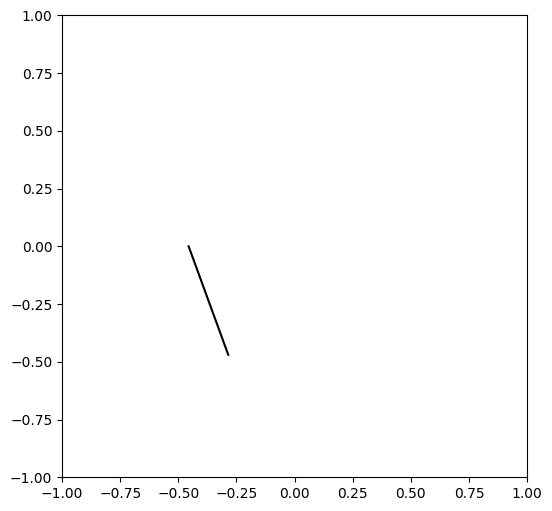

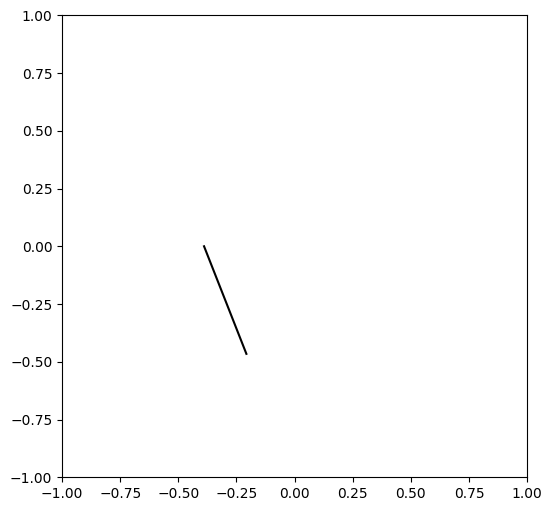

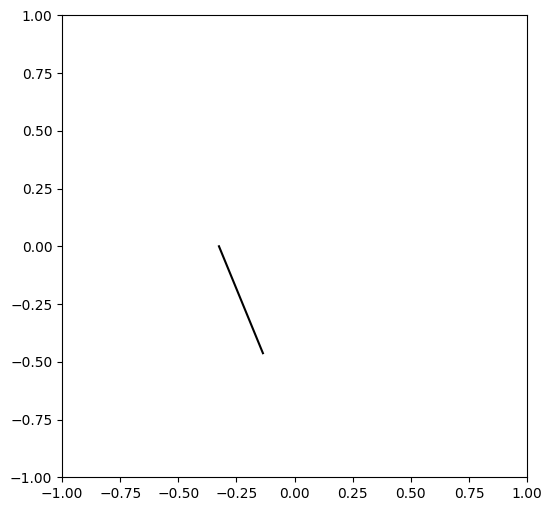

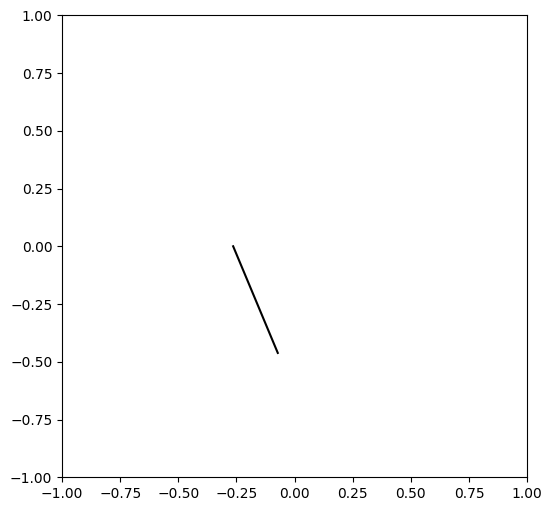

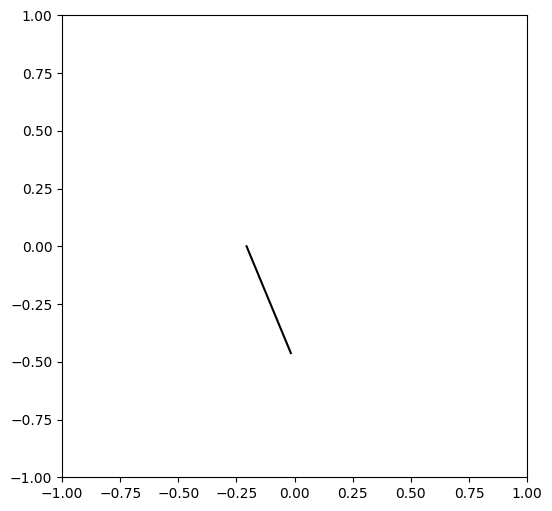

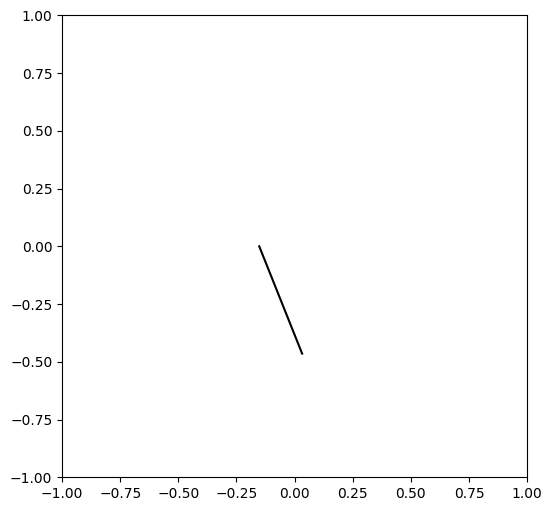

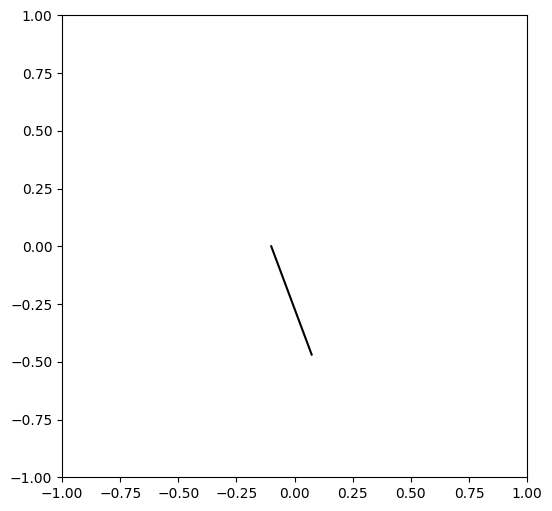

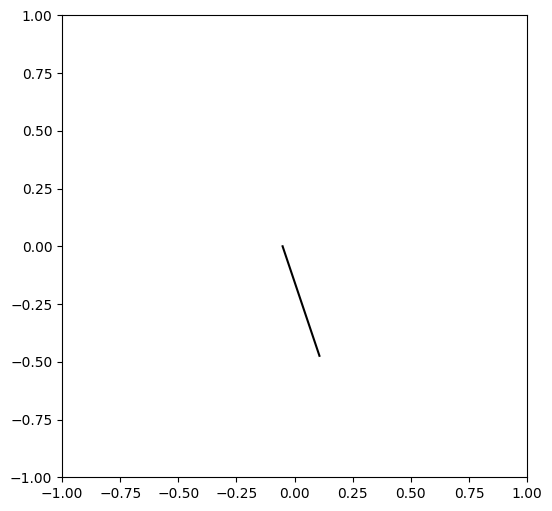

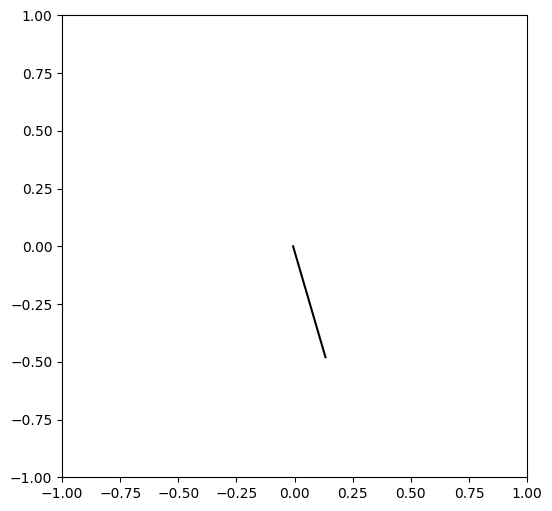

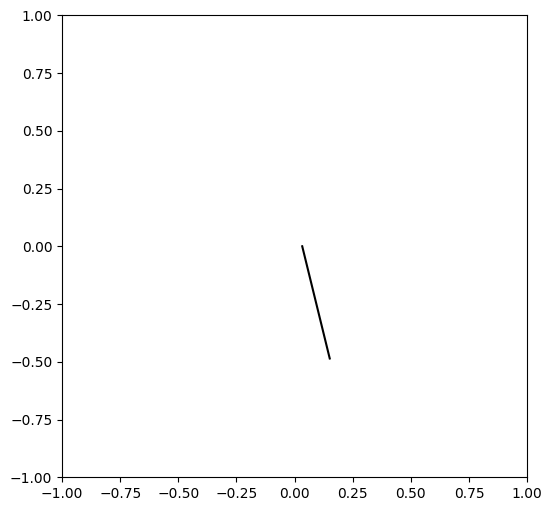

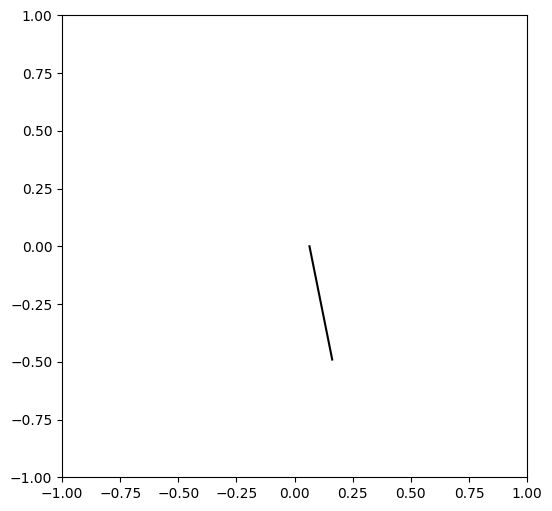

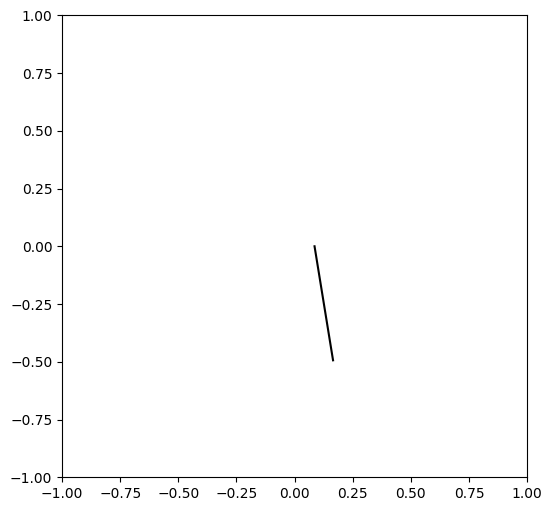

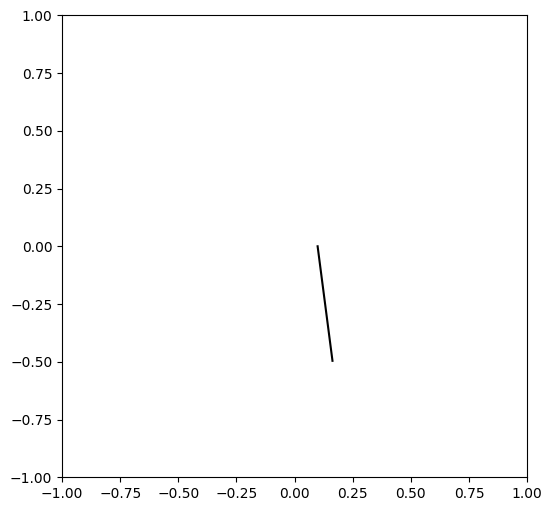

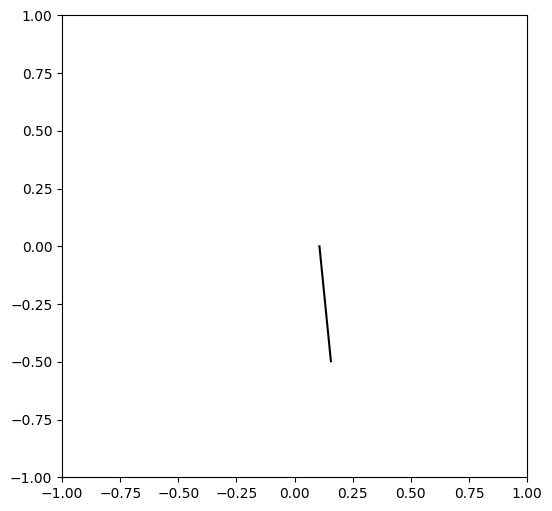

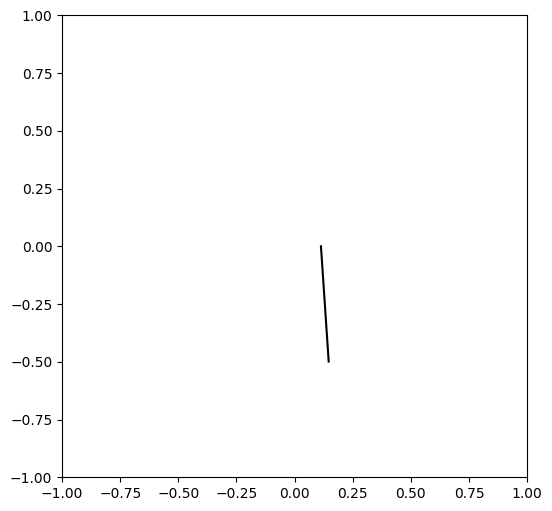

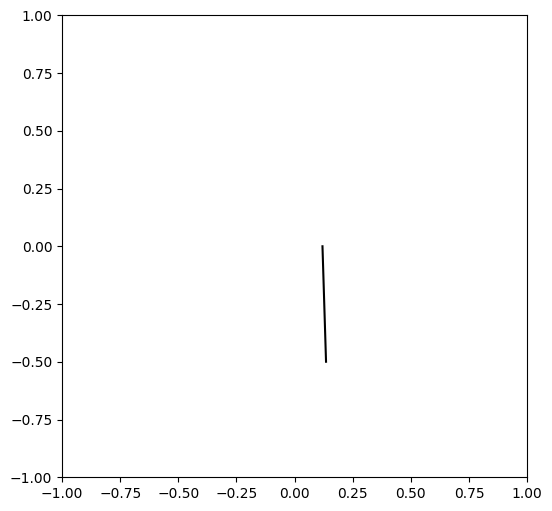

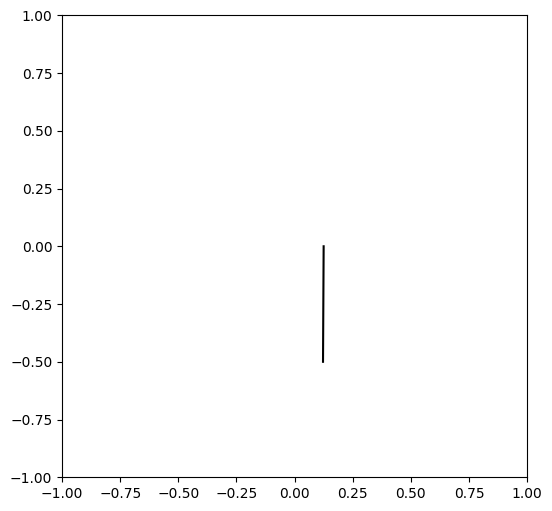

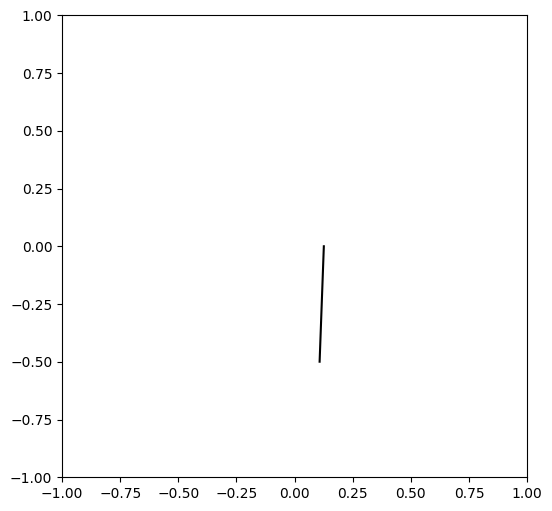

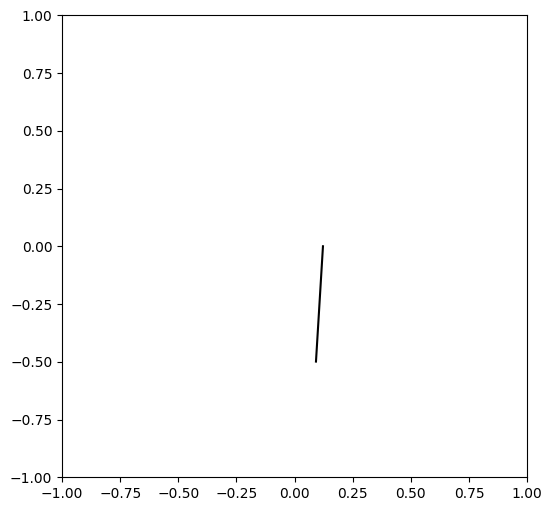

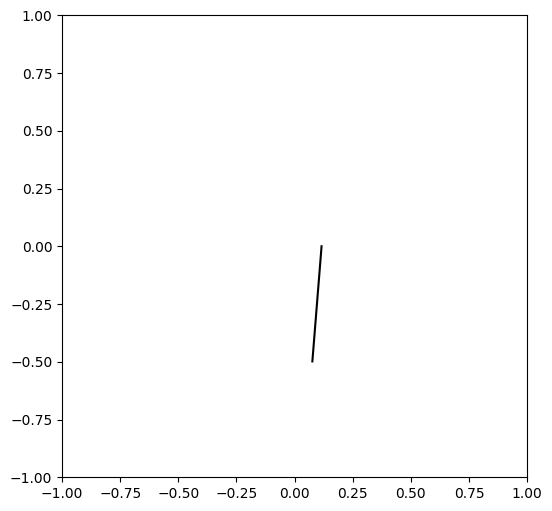

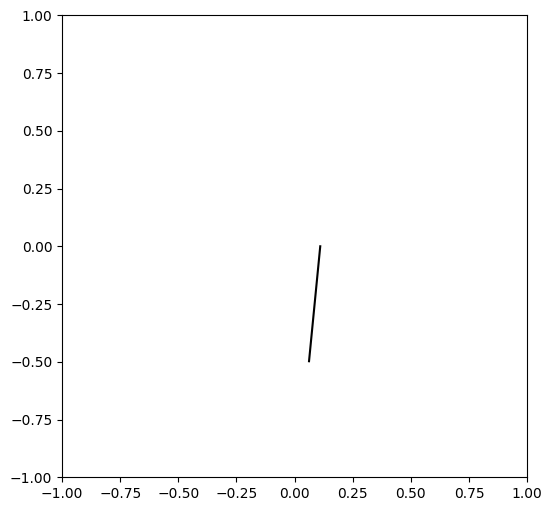

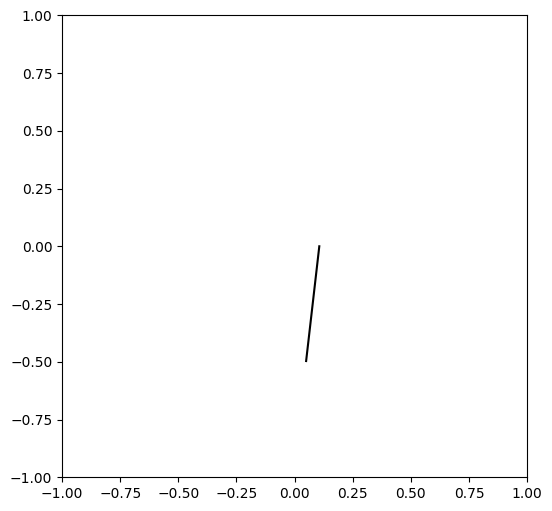

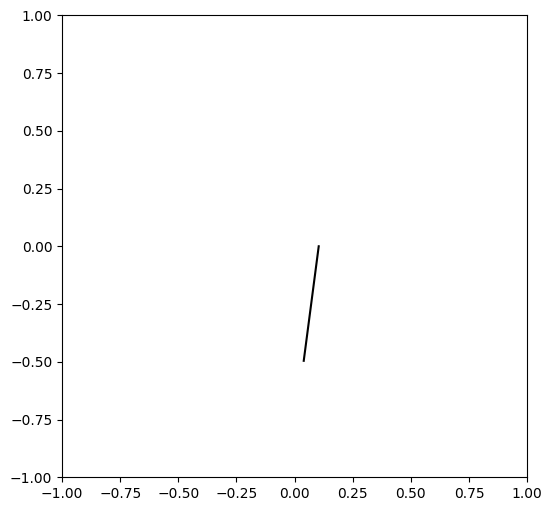

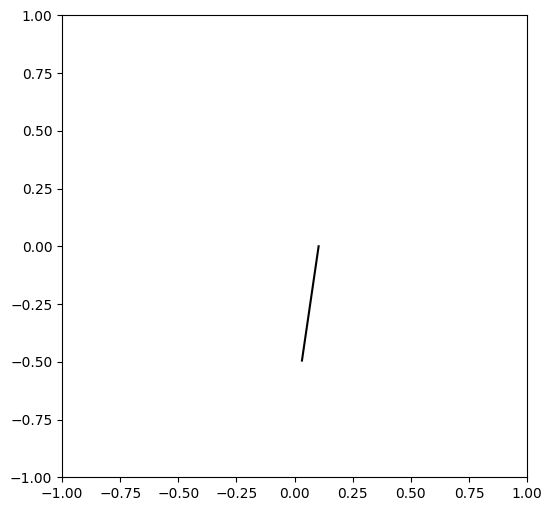

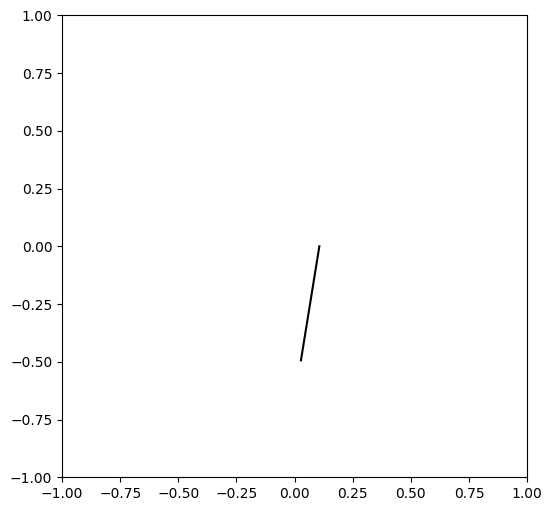

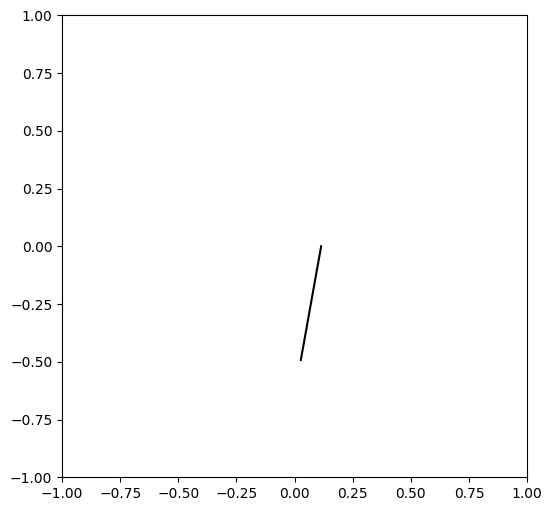

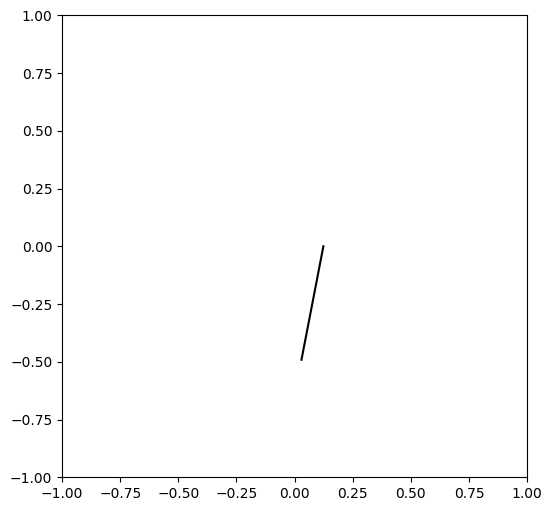

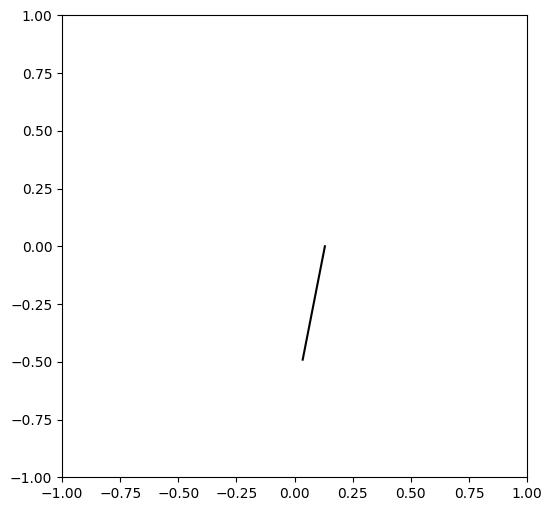

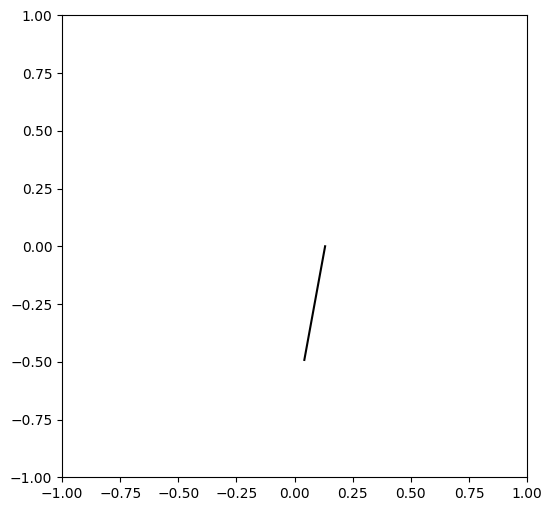

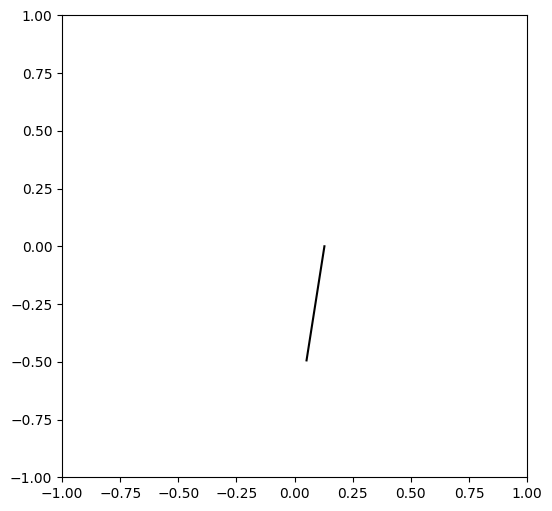

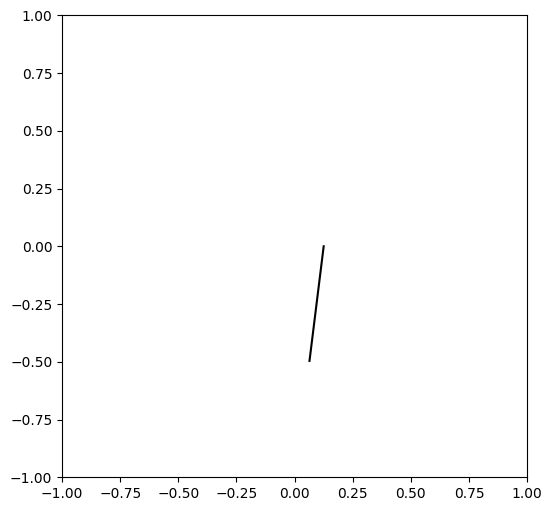

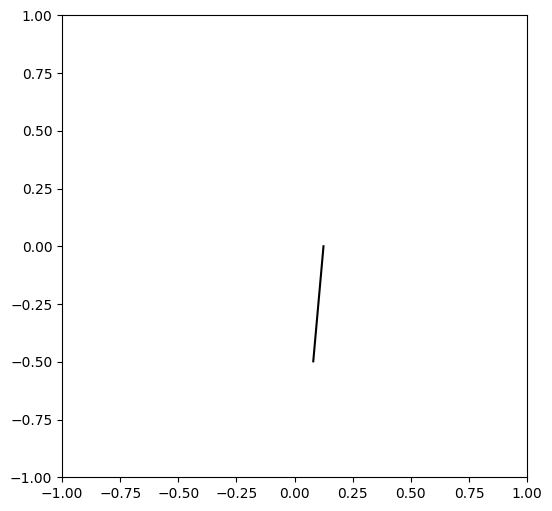

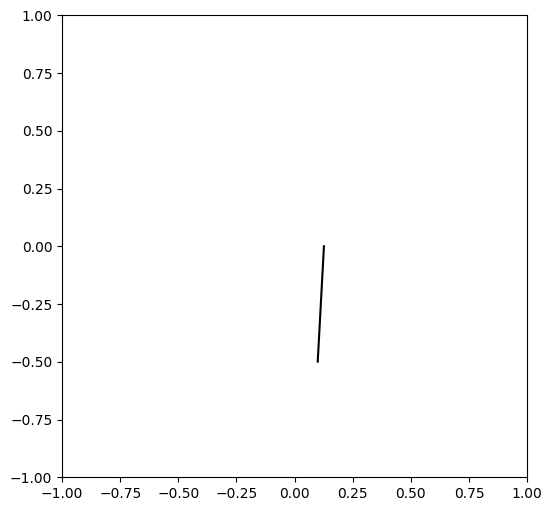

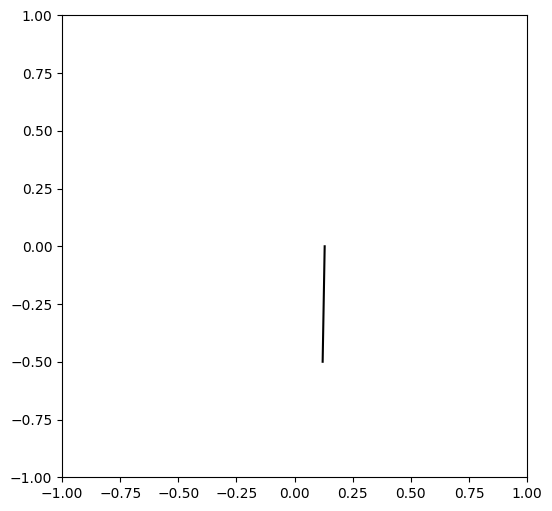

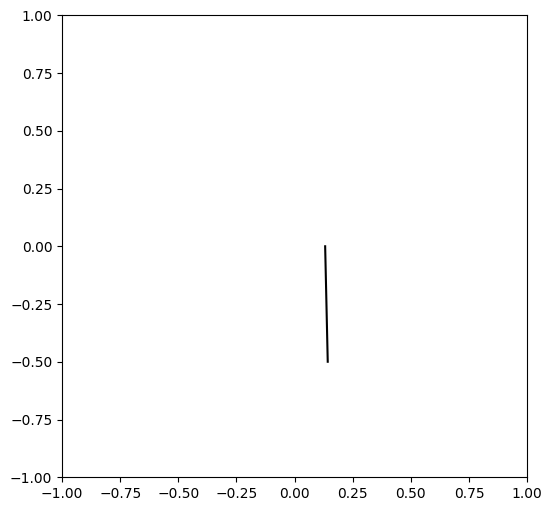

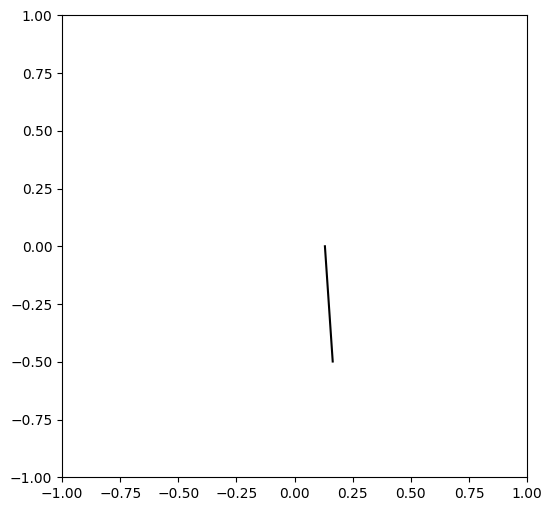

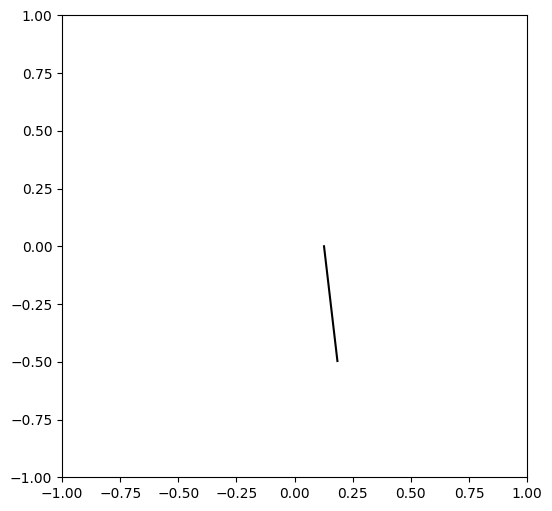

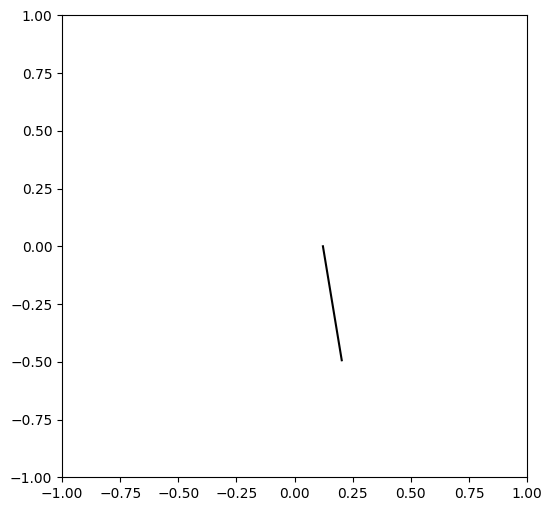

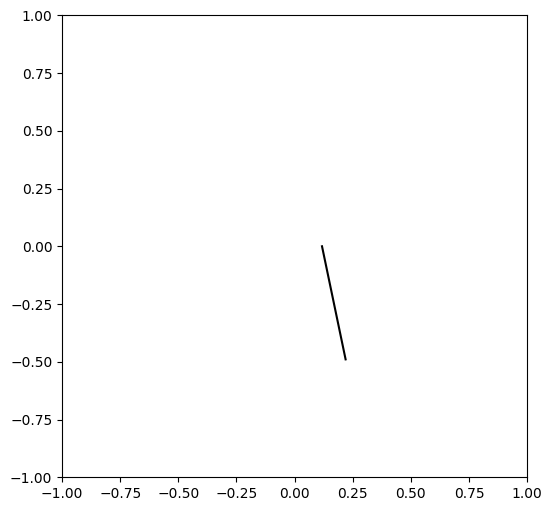

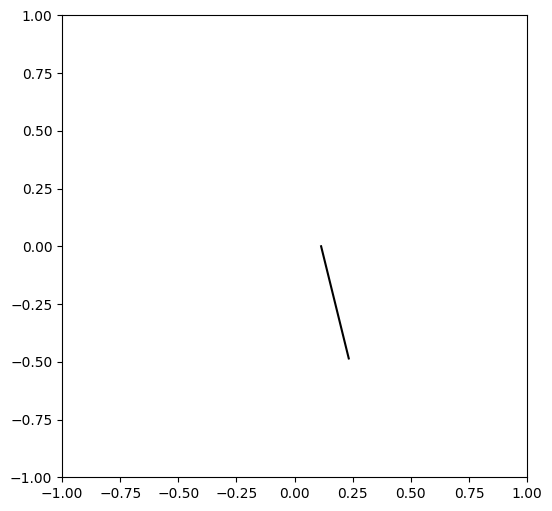

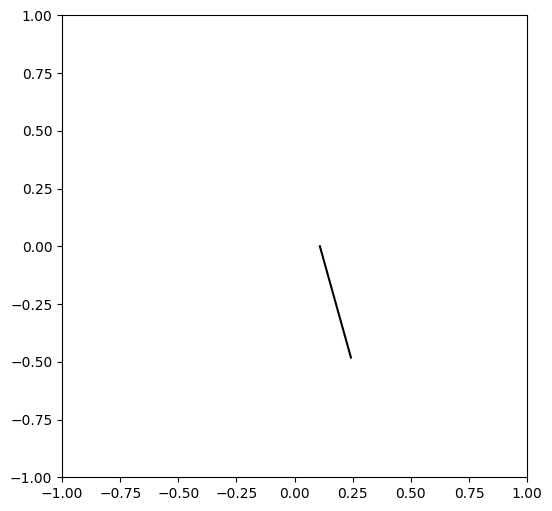

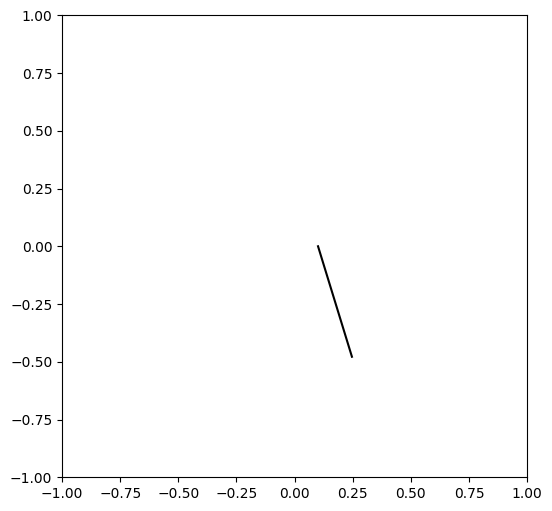

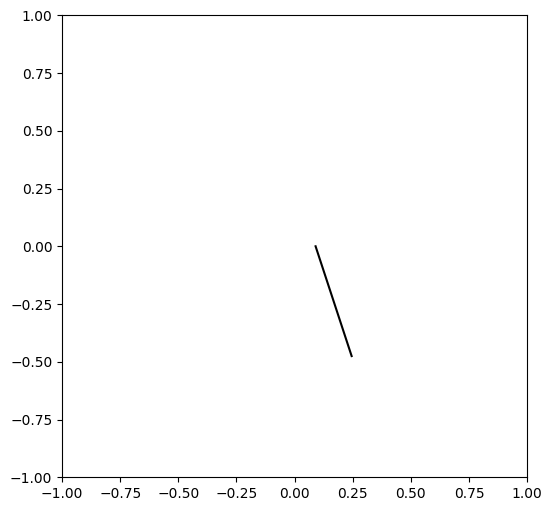

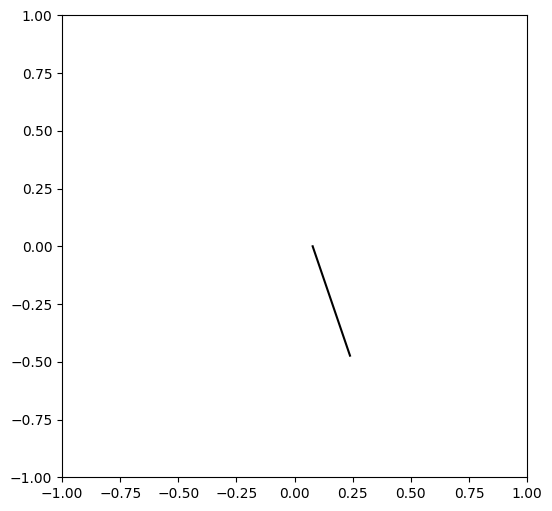

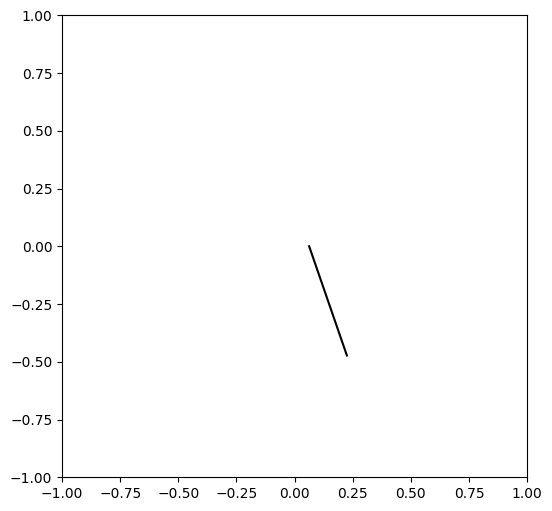

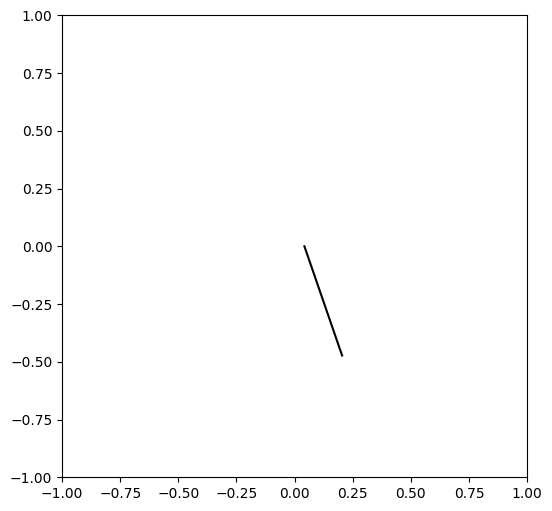

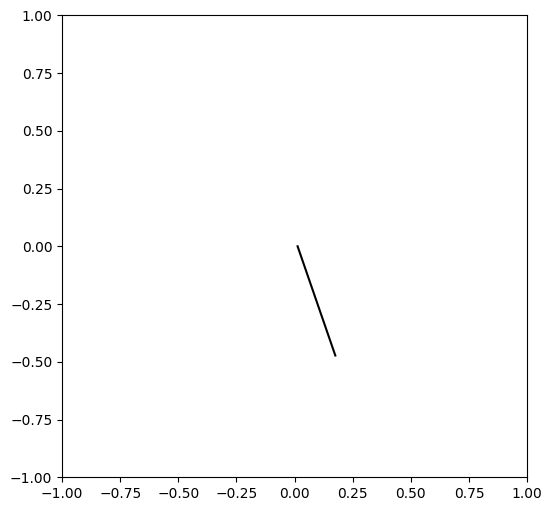

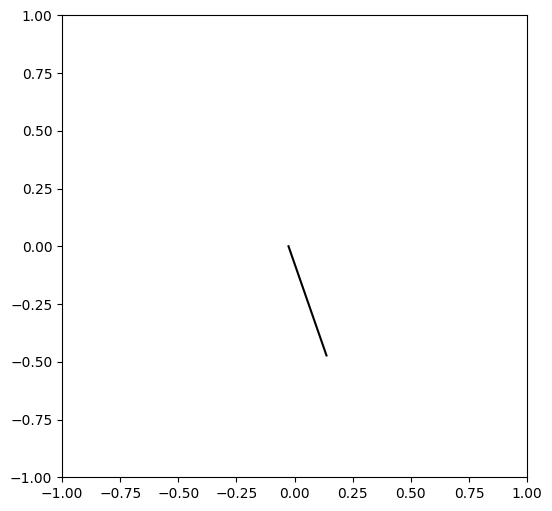

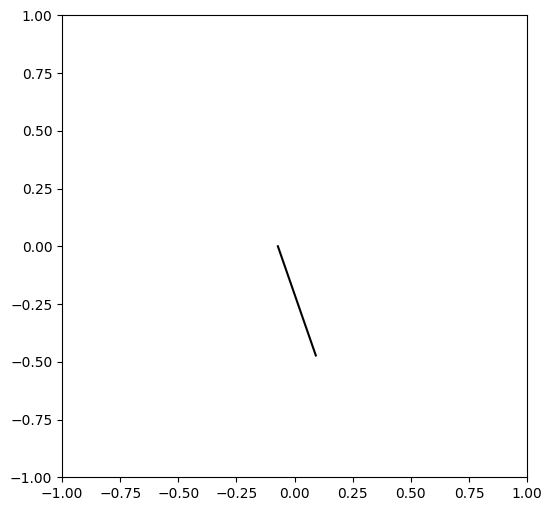

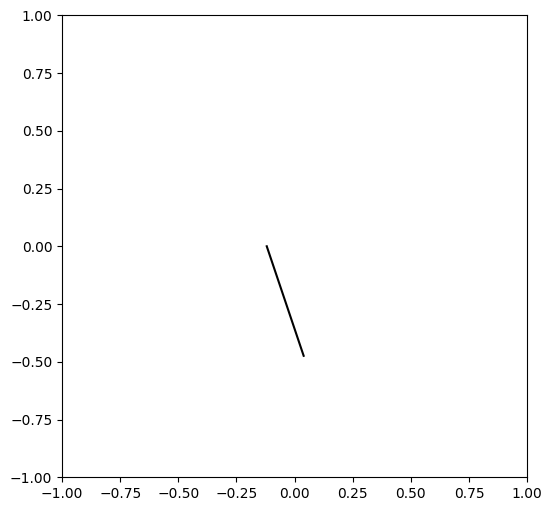

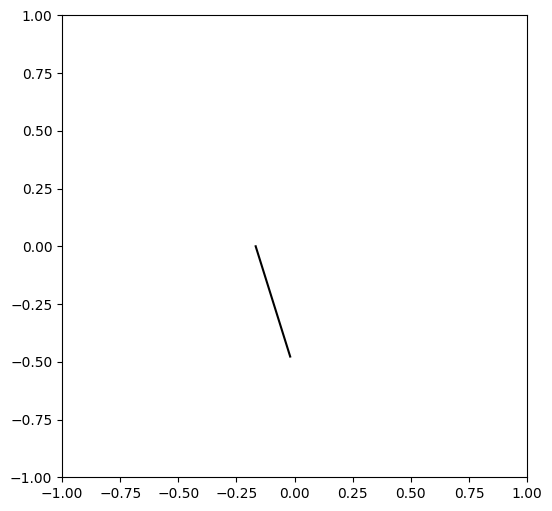

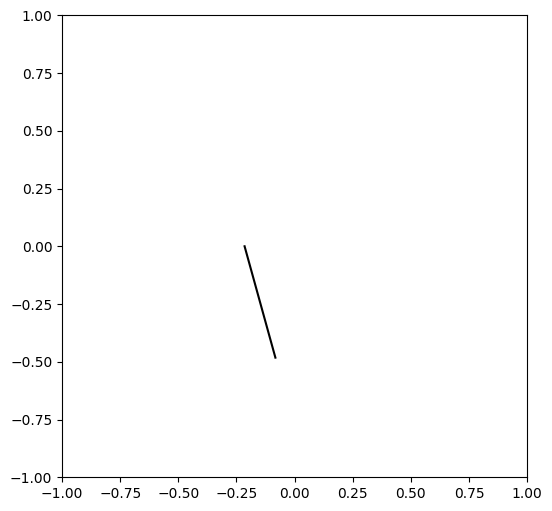

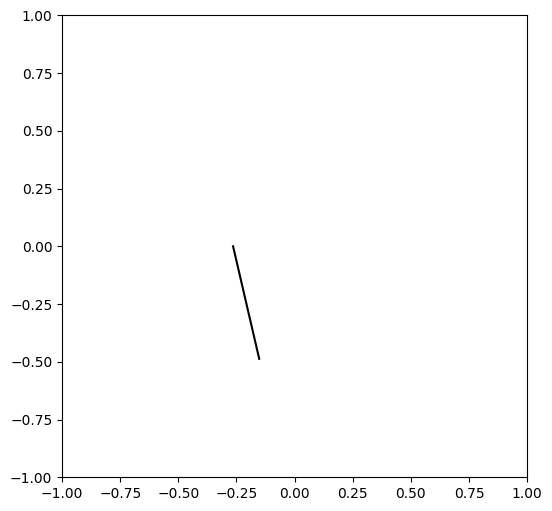

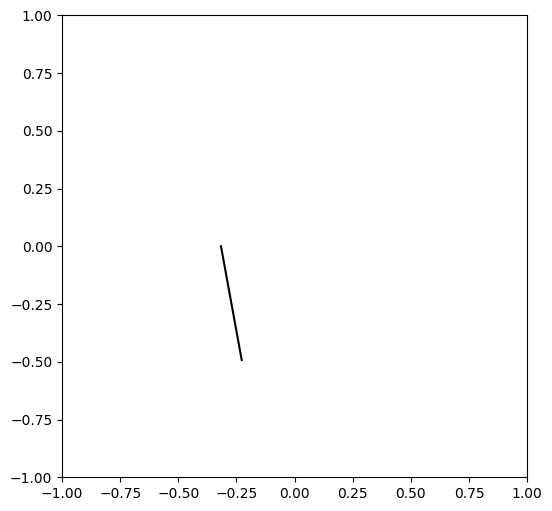

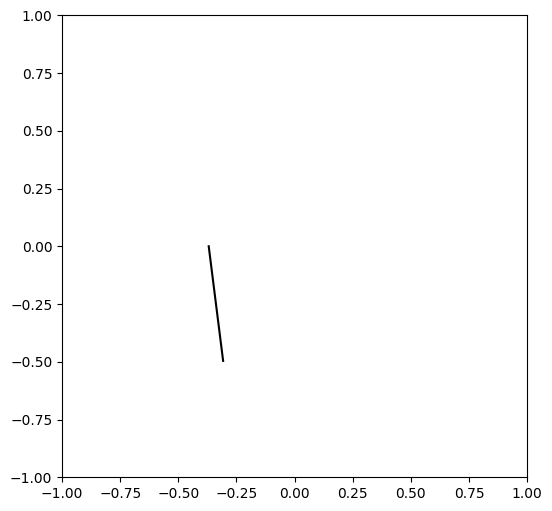

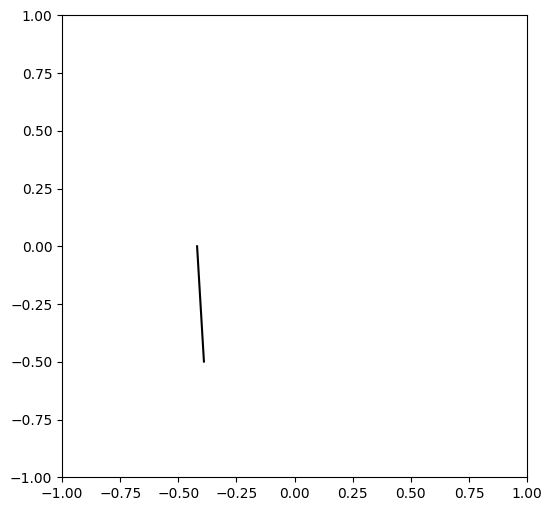

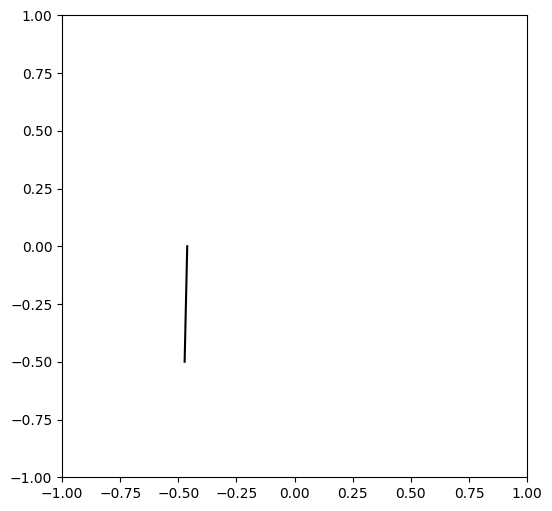

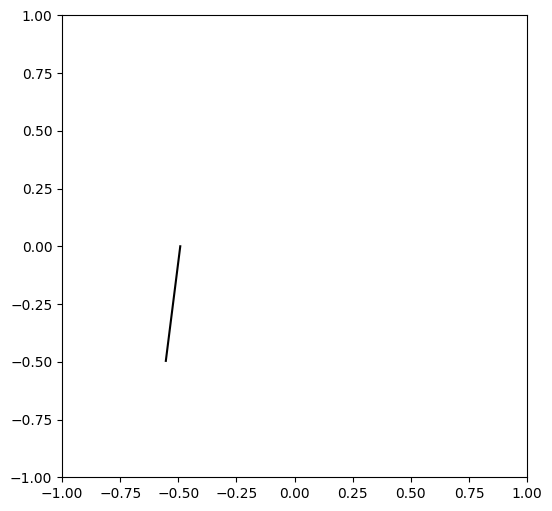

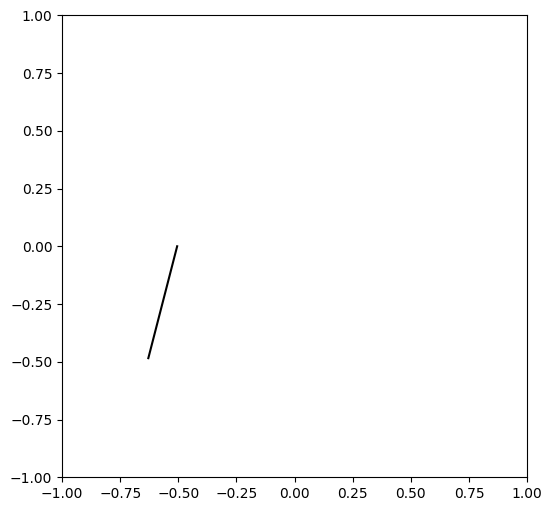

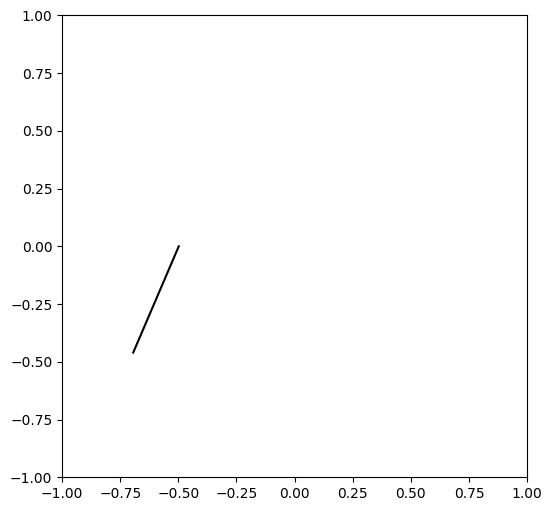

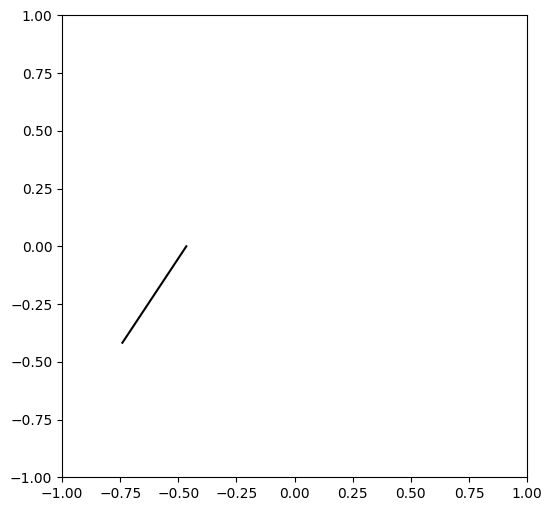

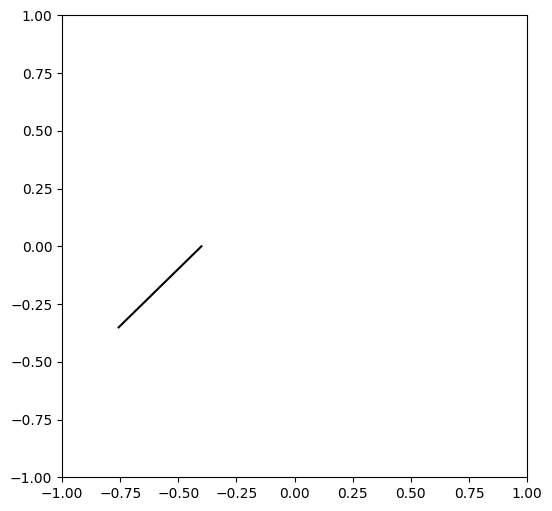

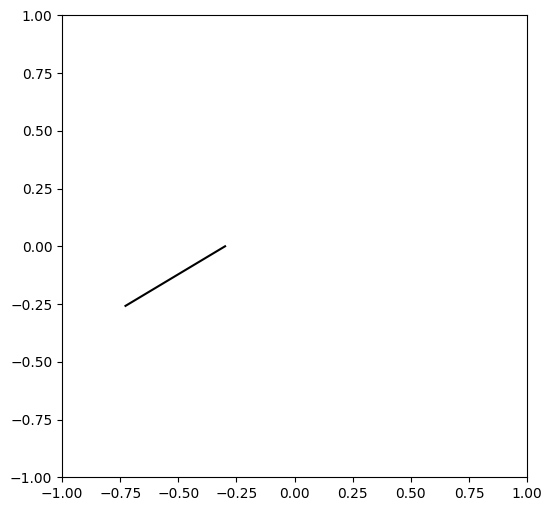

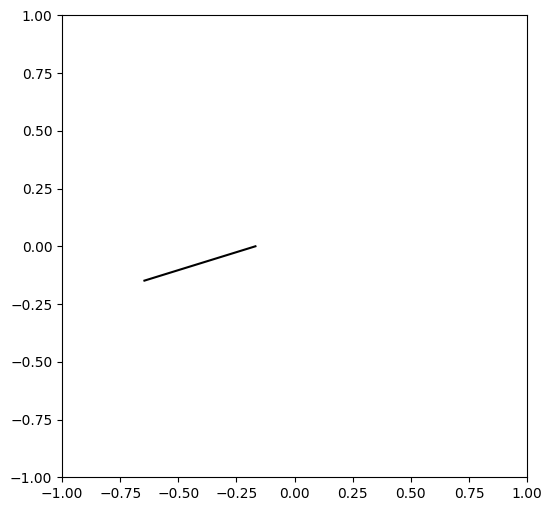

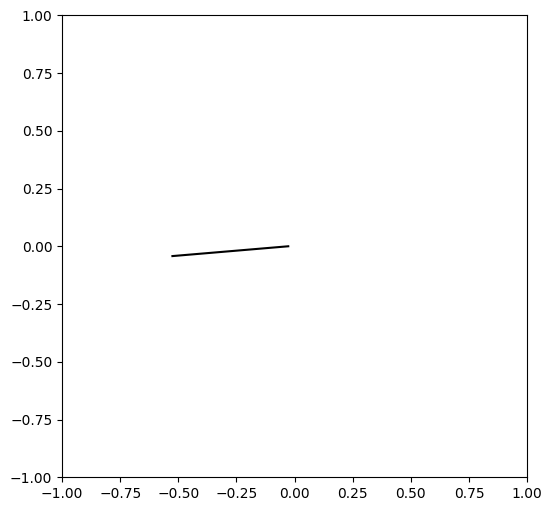

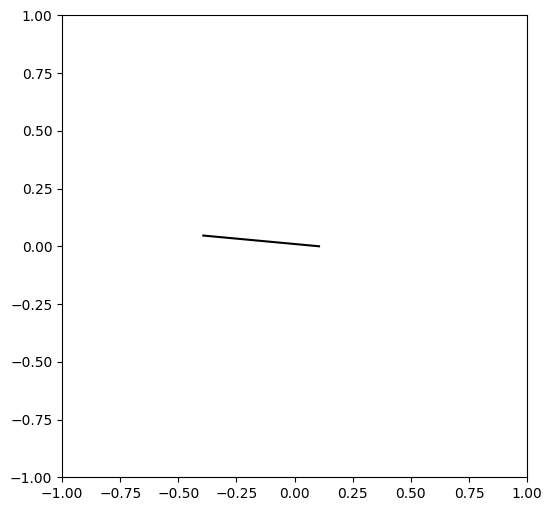

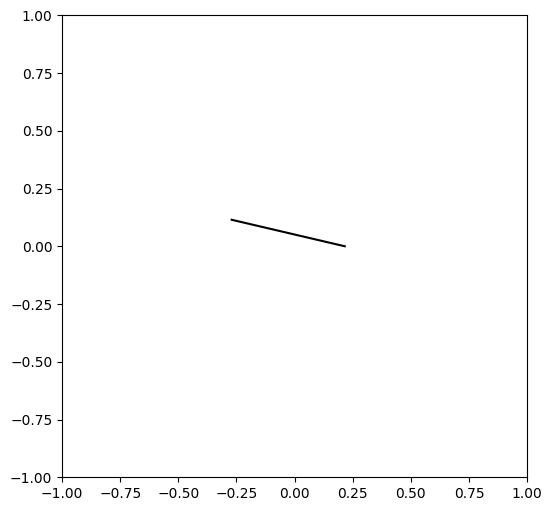

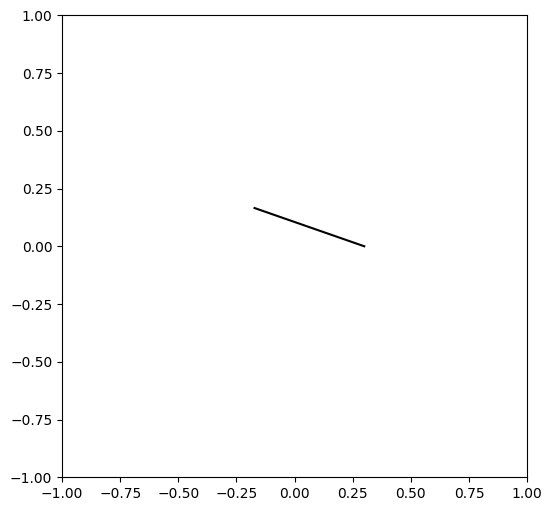

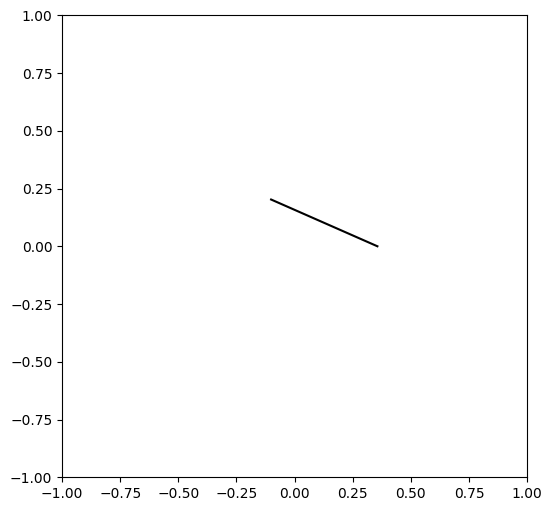

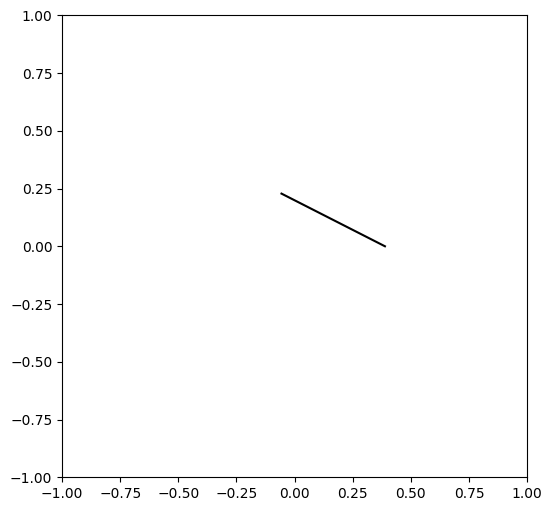

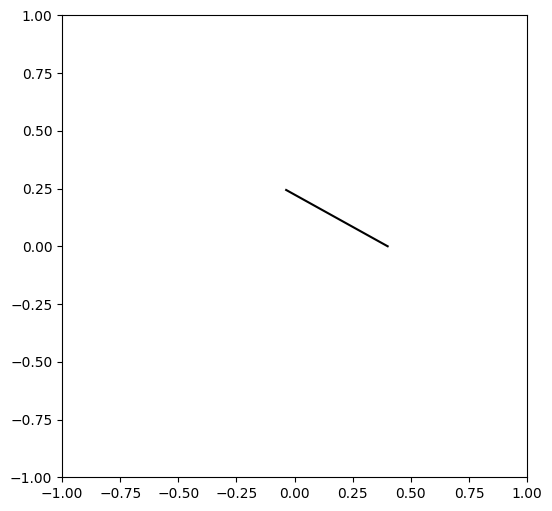

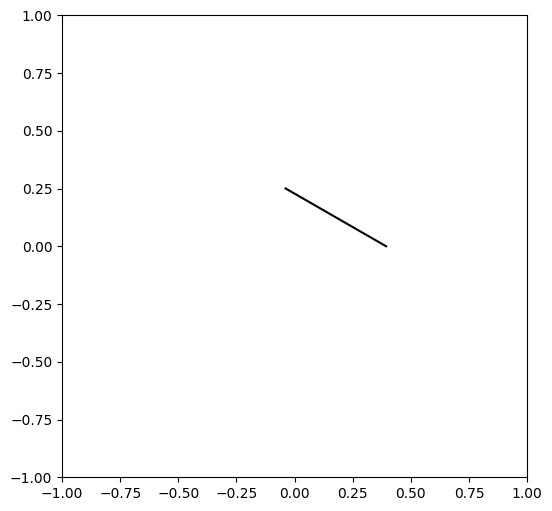

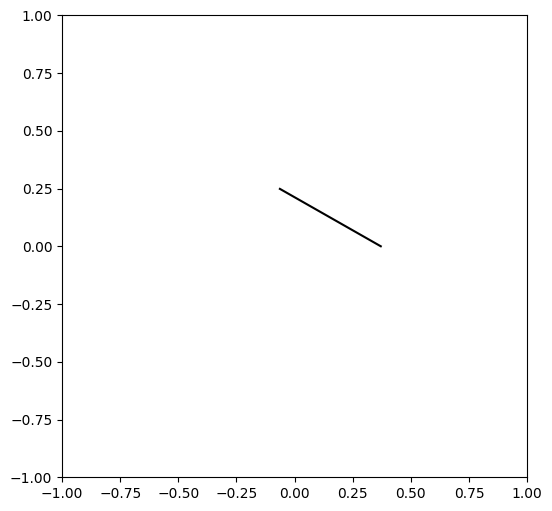

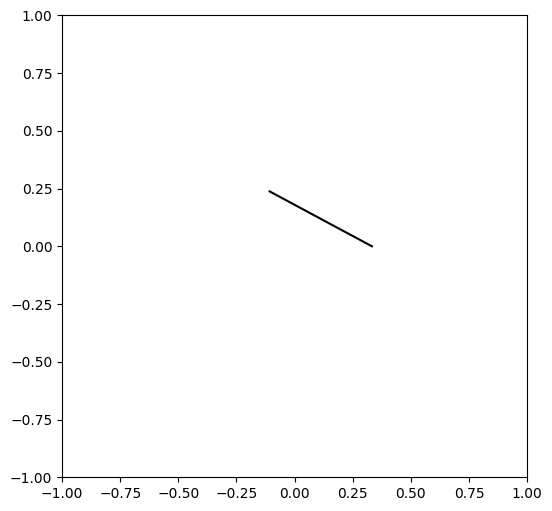

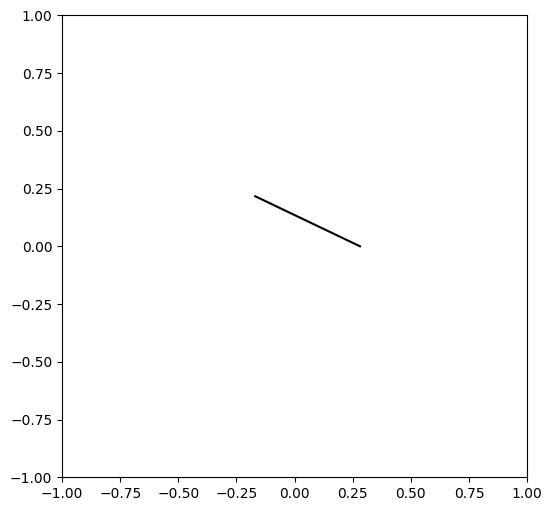

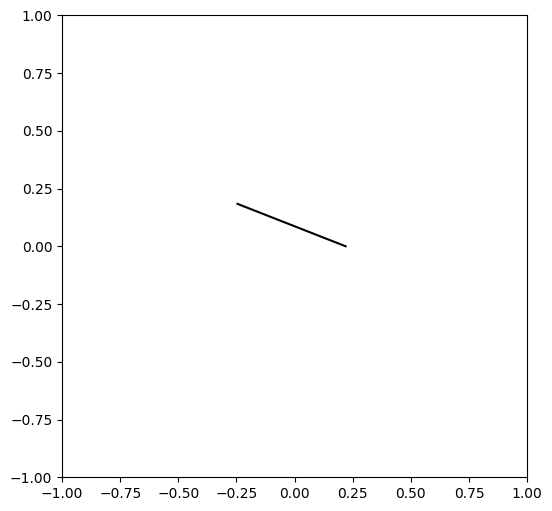

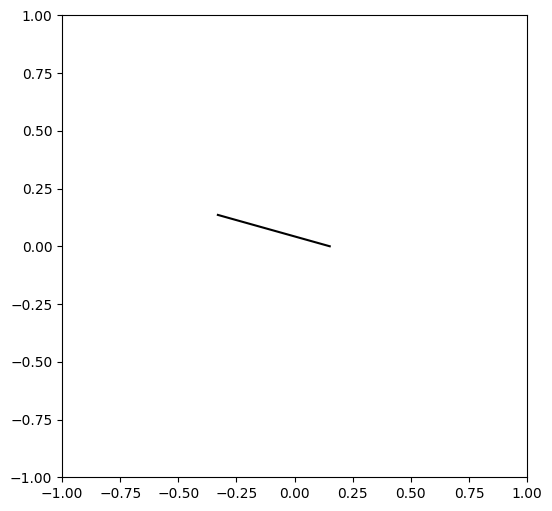

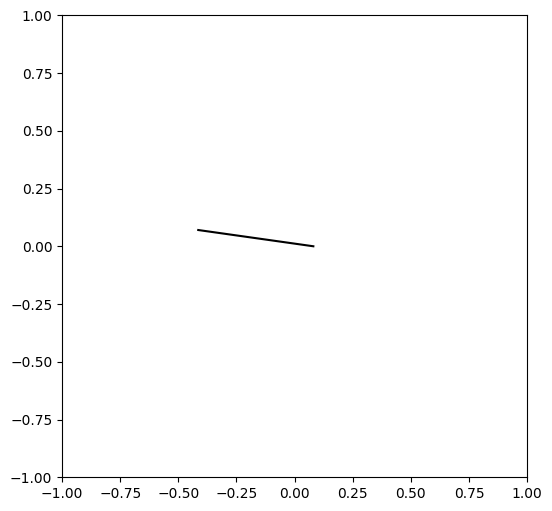

In [92]:
# 奇怪的是，scipy报了unable to solve的warning但是最后还是立起来了
for t in range(len(timepts)):
    cartpole.get_frame(result.states[:, t])

# Experiment with control library

## OCP utils

In [ ]:
class cartpole():
    def __init__(self, params=[9.8, 1.0, 0.1, 0.5]):
        self.params = params
        self.force_mag = 100.
        self.theta_threshold_radians = np.pi
        self.x_threshold = 2.4
        self.max_velocity = 10
        self.dt = 0.05
        self.lower = -self.force_mag
        self.upper = self.force_mag
        self.goal_state = [0., 0., 1., 0., 0.]
        self.goal_weights = [0.1, 0.1, 1., 1., 0.1]
        self.ctrl_penalty = 0.001

    def get_update_func(self):
        def cartpole_update(t, states, inputs, params):
            gravity, masscart, masspole, length = params
            total_mass = masspole + masscart
            polemass_length = masspole * length

            u = inputs[0]
            u = np.clip(u, self.lower, self.upper)

            x, dx, cos_th, sin_th, dth = states
            th = np.arctan2(sin_th, cos_th)

            cart_in = (u + polemass_length * dth**2 * sin_th) / total_mass
            th_acc = (gravity * sin_th - cos_th * cart_in) / \
                (length * (4./3. - masspole * cos_th**2 / total_mass))
            xacc = cart_in - polemass_length * th_acc * cos_th / total_mass

            x = x + self.dt * dx
            dx = dx + self.dt * xacc
            th = th + self.dt * dth
            dth = dth + self.dt * th_acc

            return np.array([x, dx, np.cos(th), np.sin(th), dth])
        return cartpole_update
    
    def get_frame(self, state, ax=None):
        x, dx, cos_th, sin_th, dth = state
        gravity, masscart, masspole, length = self.params

        th = np.arctan2(sin_th, cos_th)
        th_x = sin_th*length
        th_y = cos_th*length

        if ax is None:
            fig, ax = plt.subplots(figsize=(6,6))
        else:
            fig = ax.get_figure()
        ax.plot((x,x+th_x), (0, th_y), color='k')
        ax.set_xlim((-length*2, length*2))
        ax.set_ylim((-length*2, length*2))
        return fig, ax

    def get_true_obj(self):
        q = np.concatenate((self.goal_weights, [self.ctrl_penalty]))
        p = -np.sqrt(self.goal_weights) * self.goal_state
        return q, p
    
    def get_system(self):
        cartpole_update = self.get_update_func()
        cartpole_sys = ct.nlsys(updfcn=cartpole_update, outfcn=cartpole_update, inputs=1, outputs=5, states=5, params=self.params, name='cartpole_sys', dt=1)
        return cartpole_sys

In [ ]:
def uniform(shape, low, high):
    r = high - low
    return np.random.rand(*shape) * r + low

def cartpole_initx(n_batch):
    th = uniform((n_batch, 1), -2*np.pi, 2*np.pi)
    thdot = uniform((n_batch, 1), -.5, .5)
    x = uniform((n_batch, 1), -0.5, 0.5)
    xdot = uniform((n_batch, 1), -0.5, 0.5)
    xinit = np.concatenate((x, xdot, np.cos(th), np.sin(th), thdot), axis=1)
    return xinit

print(cartpole_initx(1)[0])

In [ ]:
def solve_ocp(cartpole_sys, timepts, x0, Q, R, Qf, lower, upper):
    """
        Q: n_array, n_state x n_state
        R: n_array, n_ctrl x n_ctrl
        Qf: n_array, n_state x n_state
        lower: n_array, n_ctrl x 1
        upper: n_array, n_ctrl x 1
    """
    constraints = [opt.input_range_constraint(cartpole_sys, lower, upper)]
    running_cost = opt.quadratic_cost(cartpole_sys, Q, R)
    terminal_cost = opt.quadratic_cost(cartpole_sys, Qf, None)
    result = opt.solve_ocp(cartpole_sys, timepts, x0, running_cost, constraints, terminal_cost)
    return result

## MPC utils

In [ ]:
x = np.array([1., 2., 3., 4., 5.], dtype=np.float32)
Q_test = nn.Parameter(torch.eye(5))
# calculate x.T @ Q @ x, keep gradient
print(torch.matmul(torch.matmul(torch.tensor(x).unsqueeze(0), Q_test), torch.tensor(x).unsqueeze(1)).squeeze(0).squeeze(0))

In [ ]:
# 用采样结果计算，这部分必须用torch
def cost_cartpole(x, u, Q, R, Qf, is_terminal):
    if is_terminal:
        return torch.matmul(torch.matmul(torch.tensor(x).unsqueeze(0), Qf), torch.tensor(x).unsqueeze(1)).squeeze(0).squeeze(0)
    else:
        return torch.matmul(torch.matmul(torch.tensor(x).unsqueeze(0), Q), torch.tensor(x).unsqueeze(1)).squeeze(0).squeeze(0) + \
               torch.matmul(torch.matmul(torch.tensor(u).unsqueeze(0), R), torch.tensor(u).unsqueeze(1)).squeeze(0).squeeze(0)

def VN_cartpole(x, u, Q, R, Qf):
    VN = 0
    T = x.shape[1]
    for t in range(T):
        if t == T - 1:
            VN += cost_cartpole(x[:, t], u[:, t], Q, R, Qf, True)
        else:
            VN += cost_cartpole(x[:, t], u[:, t], Q, R, Qf, False)
    return VN

def RDP_criteria_cartpole(VN_list, x_list, u_list, alpha, MPC_T, func, test=False, log_path=None):
    loss = 0
    for i in range(MPC_T - 1):
        RDP = (VN_list[i+1] + alpha * cost_cartpole(x_list[i], u_list[i], False)) - VN_list[i] # Wish RDP <= 0

        if test:
            if log_path is not None:
                with open(log_path, 'a') as f:
                    f.write(f'RDP{i}: {RDP.squeeze(1).squeeze(1)}\n')
        loss += func(RDP)

In [ ]:
Q = nn.Parameter(torch.randn(5, 5))
print(Q)
print(Q.data)

In [ ]:
def mpc_cartpole(cartpole_sys, Q, R, Qf, MPC_T, T, x_init, u_lower, u_upper):
    x = x_init

    timepts = np.arange(0, T, 1)
    lower = u_lower
    upper = u_upper

    x_list = []
    u_list = []
    VN_list = []
    for i in range(MPC_T):
        result = solve_ocp(cartpole_sys, timepts, x, Q.data, R.data, Qf.data, lower, upper)
        print(f"MPC Timestamp success? {i}: ", result.success)
        u = result.inputs[:, 0] # u: 1 x n_ctrl list
        x_list.append(x)
        u_list.append(u)
        x = result.states[:, 1] # x: 1 x n_state list
        VN_list.append(VN_cartpole(result.states, result.inputs, Q, R, Qf))
    return x_list, u_list, VN_list

## Experiments

In [ ]:
# System params
DTYPES = torch.float64
torch.set_default_dtype(DTYPES)
cartpole_ori = cartpole()
cartpole_sys = cartpole_ori.get_system()
Q = nn.Parameter(torch.randn(5, 5))
R = torch.Tensor([[1.]])
F = nn.Parameter(torch.randn(5, 5))
MPC_T = 100
T = 30
u_lower = cartpole_ori.lower
u_upper = cartpole_ori.upper

# Exp params
epochs = 500
batch_size = 2
optimizer = torch.optim.Adam([Q, F], lr=0.01)

# Train
for epoch in tqdm(range(epochs)):
    loss = 0
    for batch in range(batch_size):
        x_init = cartpole_initx(1)[0]
        x_list, u_list, VN_list = mpc_cartpole(cartpole_sys, Q.T @ Q, R, F.T @ F, MPC_T, T, x_init, u_lower, u_upper)
        loss += RDP_criteria_cartpole(VN_list, x_list, u_list, 1, MPC_T, lambda x: torch.relu(x), test=True)
    loss /= batch_size
    print(loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()